# Plots


In [34]:
# rename_methods.py
import pandas as pd
# --- config (near the top) ---
EXCLUDE_METHODS = {"LP2"}   # case-insensitive

inp = "/home/divar/projects/graphical-sampling/simulation_results/Final_Results_4_Popu_Final.csv"
out = inp  # overwrite; change to a new path if you want a backup

df = pd.read_csv(inp)
df["Method"] = df["Method"].astype(str).replace({
    "B": "NMC",
})
# --- load_df(...) after the method renames ---
df["Method"] = df["Method"].astype(str).replace({"lpm2":"LP2", "LPM2":"LP2"})
df = df[~df["Method"].str.upper().isin(EXCLUDE_METHODS)].copy()

df.to_csv(out, index=False)
print("Saved:", out)


Saved: /home/divar/projects/graphical-sampling/simulation_results/Final_Results_4_Popu_Final.csv


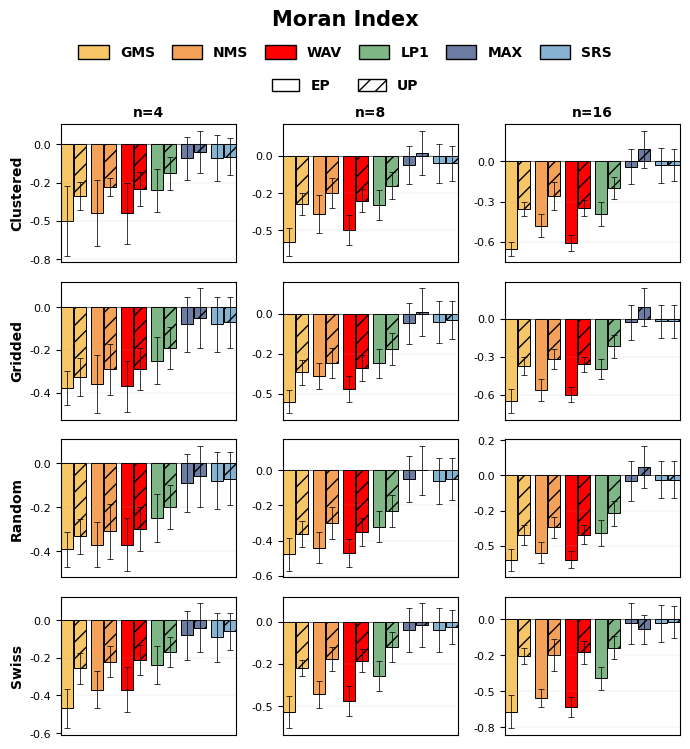

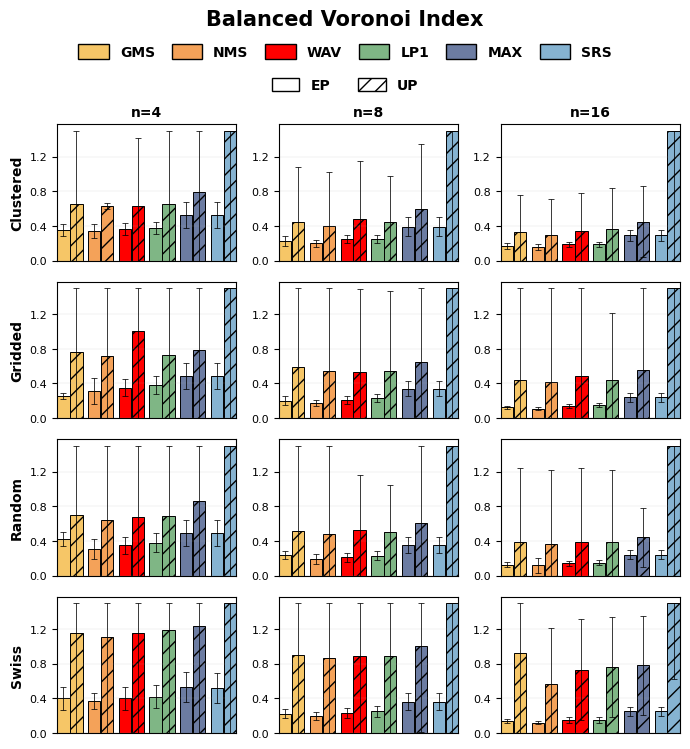

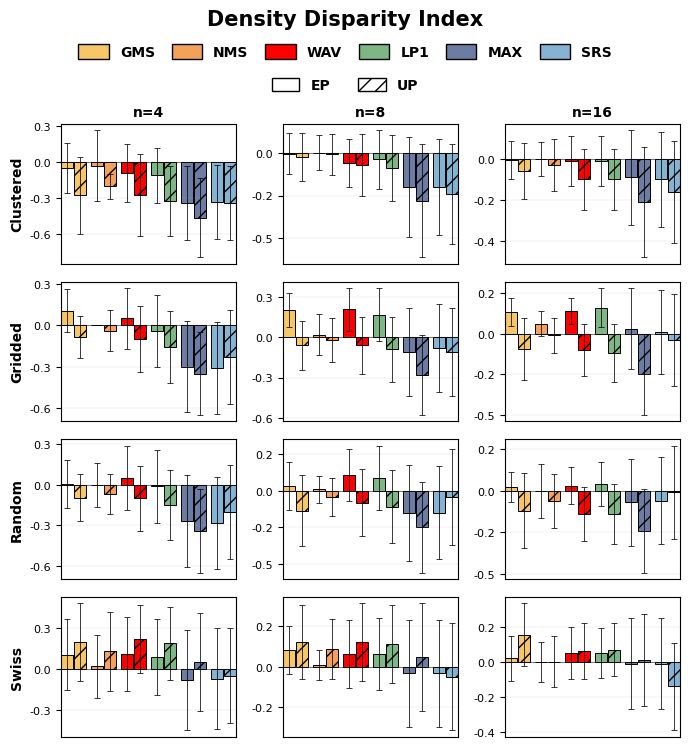

In [51]:
# paper_bars_grid.py
# 3 publication-ready bar charts with error bars:
#   Measures: I (Moran's I), L (Local Balance), D (Density)
#   Each figure mixes π=eq and π=uneq inside every subplot (hatched vs solid)
#   TRANSPOSED layout: 4 rows (Clust, Grid, Random, Swiss) × 3 cols (n=4,8,16)
# Rules:
#   - GRZ shown ONLY for Moran's I  (toggle in methods_for_measure if needed)
#   - Consistent, custom colors by method
#   - Legend on top; x-axis method labels hidden for a clean look

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker


# ---------- Paths ----------
CSV = Path("/home/divar/projects/graphical-sampling/simulation_results/Final_Results_4_Popu_Final_corrected.csv")
OUTDIR = Path("/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
MEASURES = [("I", "Moran Index"), ("L", "Balanced Voronoi Index"), ("D", "Density Disparity Index")]
POPUS = [("clust", "Clustered"), ("grid", "Gridded"), ("random", "Random"), ("swiss", "Swiss")]
NS = [4, 8, 16]
ERR_KW = dict(
    capsize=2,      # shorter caps = "narrower"
    capthick=0.6,   # thinner cap line
    elinewidth=0.6, # thinner vertical error line
    ecolor="black",
    alpha=0.9
)
# Display settings
HIDE_X_LABELS = True
SHOW_GRZ_ONLY_FOR_I = True

# Side-by-side bar sizing (prevents overlap)
BAR_WIDTH = 0.40   # width of each (eq/uneq) bar
BAR_SEP   = 0.02   # gap between eq and uneq at the same method
Y_MAX = 1.5        # clip means/std and cap error bars

# ---- Color map (last one wins). Keep as in your latest post ----
COLOR_MAP = {
    "MAX": "#6C7CA2",  # pastel indigo
    "SRS": "#86B3D1",  # pastel blue
    "WAV": "#FF0000",  # red
    "LP1": "#7FB685",  # pastel green
    "NMS": "#F4A259",  # soft orange
    "GMS": "#F6C667",  # soft amber
}


_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
def fallback_color(i: int) -> str:
    return _cycle[i % len(_cycle)]

# ---------- Data loading ----------
def load_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # remove LP2 everywhere (case-insensitive)
    df = df[~df["Method"].str.contains(r"^lp2$", case=False, na=False)].copy()

    # normalize names
    if "Popu" in df.columns:
        df["Popu"] = df["Popu"].astype(str).str.lower().replace({"cluster": "clusted"})
    if "pi" in df.columns:
        df["pi"] = df["pi"].astype(str).str.lower().replace(
            {"equal": "eq", "uneq": "uneq", "unequal": "uneq", "uequal": "uneq"}
        )

    # Some files use n vs N; standardize to 'n'
    if "N" in df.columns and "n" not in df.columns:
        df = df.rename(columns={"N": "n"})
    df["n"] = pd.to_numeric(df["n"], errors="coerce").astype("Int64")

    df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
    df["std"]  = pd.to_numeric(df["std"],  errors="coerce")

    # Keep only I/L/D (ignore Voronoi)
    df = df[df["Measure"].isin(["I", "L", "D"])]

    # unify labels if needed
    df["Method"] = df["Method"].astype(str).replace({
        "nMC": "NMS",
        "NMC": "NMS",
        "GRZ": "GMS",  # GRZ is a special case, shown only for I
    })

    return df.dropna(subset=["n", "mean", "std", "Popu", "pi", "Method", "Measure"]).copy()

# Preferred method order per measure (strict order kept even if some are missing)
METHOD_ORDER_BY_MEASURE = {
    "I": ["GMS", "NMS", "WAV", "LP1", "MAX", "SRS"],
    "L": ["GMS", "NMS", "WAV", "LP1", "MAX", "SRS"],
    "D": ["GMS", "NMS", "WAV", "LP1", "MAX", "SRS"],
}

def methods_for_measure(df_measure: pd.DataFrame, measure_code: str) -> list[str]:
    """Return the method order for an entire measure (union across eq/uneq),
       respecting METHOD_ORDER_BY_MEASURE exactly."""
    pref = METHOD_ORDER_BY_MEASURE.get(measure_code, [])
    present_all = df_measure["Method"].astype(str).unique().tolist()

    ordered = [m for m in pref if m in present_all]
    extras = sorted([m for m in present_all if m not in ordered])
    ordered += extras

    # If you really want to hide GRZ for non-I, uncomment below:
    # if SHOW_GRZ_ONLY_FOR_I and measure_code != "I":
    #     ordered = [m for m in ordered if m != "GRZ"]
    return ordered

def build_series_for_methods(sub: pd.DataFrame, methods: list[str]):
    """Return arrays aligned to 'methods' for mean/std; NaNs for missing."""
    m2 = sub.set_index(sub["Method"].astype(str))[["mean","std"]].astype(float)
    # clip raw mean/std to Y_MAX and std >= 0
    m2 = m2.clip(upper=Y_MAX)
    m2["std"] = m2["std"].clip(lower=0)

    vals = np.array([m2.loc[m, "mean"] if m in m2.index else np.nan for m in methods], dtype=float)
    errs = np.array([m2.loc[m, "std"]  if m in m2.index else np.nan for m in methods], dtype=float)
    return vals, errs

def yerr_for_measure(measure_code: str, vals: np.ndarray, errs: np.ndarray):
    """Asymmetric yerr for Local Balance clipped at 0; symmetric otherwise.
       Also cap the *upper* error so mean+err never exceeds Y_MAX."""
    errs = np.where(np.isnan(vals), 0.0, errs)
    errs = np.clip(errs, 0, None)

    upper_cap = np.maximum(0.0, Y_MAX - np.nan_to_num(vals, nan=Y_MAX))
    err_up = np.minimum(errs, upper_cap)

    if measure_code == "L":
        lower = np.minimum(errs, np.maximum(vals, 0.0))
        return np.vstack([lower, err_up])   # asymmetric for L
    else:
        return err_up                       # symmetric for I & D

# ---------- Plotting (TRANSPOSED) ----------
def plot_measure_combined(measure_code: str, measure_name: str, df: pd.DataFrame):
    """One figure per measure; TRANSPOSED layout:
       rows = Populations, cols = n values. Each subplot shows eq vs uneq."""
    dfx = df[df["Measure"] == measure_code].copy()
    if dfx.empty:
        return

    # Global method order for this measure (kept everywhere)
    methods = methods_for_measure(dfx, measure_code)
    if not methods:
        return
    legend_methods = methods[:]  # for the top legend

    # Figure: rows=len(POPUS), cols=len(NS)  <-- TRANSPOSED
    FIGSIZE = (7.0, 7.6)  # width, height in inches (two-column)
    fig, axs = plt.subplots(
        nrows=len(POPUS), ncols=len(NS),
        figsize=FIGSIZE, sharey=False, constrained_layout=False
    )

    fig.subplots_adjust(top=0.80)  # headroom for legends/title

    x = np.arange(len(methods))
    cols = [COLOR_MAP.get(m, fallback_color(i)) for i, m in enumerate(methods)]
    x_eq   = x - (BAR_WIDTH/2 + BAR_SEP/2)
    x_uneq = x + (BAR_WIDTH/2 + BAR_SEP/2)

    for r, (pop_code, pop_label) in enumerate(POPUS):
        for c, n in enumerate(NS):
            ax = axs[r, c]
            sub_eq   = dfx[(dfx["n"] == n) & (dfx["Popu"] == pop_code) & (dfx["pi"] == "eq")]
            sub_uneq = dfx[(dfx["n"] == n) & (dfx["Popu"] == pop_code) & (dfx["pi"] == "uneq")]

            ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
            ax.grid(axis="y", linewidth=0.3, alpha=0.4)
            # round y-ticks to 1 decimal and make them smaller
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
            ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))  # fewer ticks (optional)
            ax.tick_params(axis='y', labelsize=8)                      # smaller labels

            vals_eq,   errs_eq   = build_series_for_methods(sub_eq, methods)
            vals_uneq, errs_uneq = build_series_for_methods(sub_uneq, methods)
            yerr_eq   = yerr_for_measure(measure_code, vals_eq,   errs_eq)
            yerr_uneq = yerr_for_measure(measure_code, vals_uneq, errs_uneq)

            ax.bar(x_eq,   vals_eq,   width=BAR_WIDTH, yerr=yerr_eq,   color=cols, hatch="",
                   capsize=3, edgecolor="black", linewidth=0.7, error_kw=ERR_KW)
            ax.bar(x_uneq, vals_uneq, width=BAR_WIDTH, yerr=yerr_uneq, color=cols, hatch="//",
                   capsize=3, edgecolor="black", linewidth=0.7, error_kw=ERR_KW)

            # Local Balance non-negative
            if measure_code == "L":
                ymin, ymax = ax.get_ylim()
                ax.set_ylim(bottom=0, top=ymax)

            # x-axis labels
            if HIDE_X_LABELS:
                ax.set_xticks([]); ax.tick_params(axis="x", length=0)
            else:
                ax.set_xticks(x); ax.set_xticklabels(methods, rotation=45, ha="right")

            # Titles/labels for TRANSPOSED layout
            if r == 0:
                ax.set_title(f"n={n}", fontweight="bold", fontsize=10)
            if c == 0:
                ax.set_ylabel(pop_label, fontweight="bold", fontsize=10)

            # breathing room so caps don't clip
            pad = BAR_WIDTH + BAR_SEP
            ax.set_xlim(-pad, len(methods) - 1 + pad)

    # --- METHOD legend: bigger colored rectangles, centered at top ---
    method_patches = [
        mpatches.Patch(facecolor=COLOR_MAP.get(m, fallback_color(i)),
                       edgecolor="black", label=m)
        for i, m in enumerate(legend_methods)
    ]
    fig.legend(handles=method_patches,
               loc="upper center", bbox_to_anchor=(0.5, 0.95),
               ncol=min(8, len(method_patches)), frameon=False,
               fontsize=15, handlelength=2.2, handleheight=1.2,
               columnspacing=1.2, labelspacing=0.6,
               prop={"weight": "bold", "size": 10})

    # --- π legend: centered below methods legend ---
    pi_patches = [
        mpatches.Patch(facecolor="white", edgecolor="black", hatch="",  label="EP"),
        mpatches.Patch(facecolor="white", edgecolor="black", hatch="//", label="UP"),
    ]
    fig.legend(handles=pi_patches, loc="upper center",
               bbox_to_anchor=(0.5, 0.90), ncol=2, frameon=False,
               fontsize=15, handlelength=2.0, handleheight=1.0, borderaxespad=0.2,
               prop={"weight": "bold", "size": 10})

    # --- Title ---
    fig.suptitle(f"{measure_name}", fontsize=15, y=0.98, fontweight="bold")

    # keep space for legends/title
    fig.tight_layout(rect=[0, 0, 1, 0.92])

    # ensure OUTDIR exists
    OUTDIR.mkdir(parents=True, exist_ok=True)

    base = OUTDIR / f"{measure_code}"        # no extension here

    fig.savefig(base.with_suffix(".png"), dpi=600, bbox_inches="tight")
    fig.savefig(base.with_suffix(".pdf"),          bbox_inches="tight")



def main():
    df = load_df(CSV)
    for code, name in MEASURES:
        plot_measure_combined(code, name, df)
    plt.show()

if __name__ == "__main__":
    main()


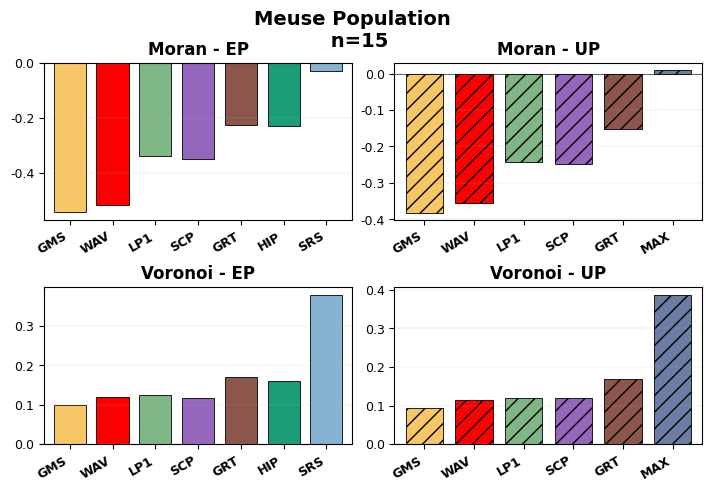

In [46]:
# --- 2x2 bars for Meuse (n=15), all data embedded ---
# Subplots: Moran eq / Moran uneq / Voronoi eq / Voronoi uneq
# Unequal bars use hatch //, equal bars solid.

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

# ---------- DATA (n = 15) ----------
# Method keys we’ll use (union across panes):
# GRZ, WAV, LP1, SCPS, GRTS, HIP, SRS, MAX

# MORAN (I_B), Equal π
moran_eq = {
    "GMS":  -0.544167,   # your method
    "WAV":  -0.518,
    "LP1":  -0.338,      # lpm1
    "SCP": -0.351,
    "GRT": -0.226,
    "HIP":  -0.230,
    "SRS":  -0.030,      # srswor
    # MAX not present for equal in table
}

# MORAN (I_B), Unequal π
moran_uneq = {
    "GMS":  -0.382228,   # your method
    "WAV":  -0.354,
    "LP1":  -0.244,
    "SCP": -0.247,
    "GRT": -0.153,
    "MAX":   0.009,      # maxent
    # HIP, SRS not present for unequal in table
}

# VORONOI (B), Equal π
voro_eq = {
    "GMS":   0.099278,   # your method
    "WAV":   0.119,
    "LP1":   0.125,
    "SCP":  0.118,
    "GRT":  0.170,
    "HIP":   0.160,
    "SRS":   0.379,
}

# VORONOI (B), Unequal π
voro_uneq = {
    "GMS":   0.093827,   # your method
    "WAV":   0.115,
    "LP1":   0.121,
    "SCP":  0.120,
    "GRT":  0.170,
    "MAX":   0.387,
}

# ---------- Appearance ----------
# Preferred global order (filtered per pane to what's present)
METHOD_ORDER = ["GMS", "WAV", "LP1", "SCP", "GRT", "HIP", "SRS", "MAX"]

COLOR_MAP = {
   "GMS":  "#F6C667",  # warm amber
    "WAV":  "#FF0000",  # red (as requested)
    "LP1":  "#7FB685",  # green
    "SCP": "#9467BD",  # purple
    "GRT": "#8C564B",  # brown
    "HIP":  "#1B9E77",  # teal
    "SRS":  "#86B3D1",  # light blue
    "MAX":  "#6C7CA2",  # indigo

}

def plot_panel(ax, data_dict, title, hatch=False):
    """Bar panel for a single (measure, π) dict."""
    methods_present = [m for m in METHOD_ORDER if m in data_dict]
    x = np.arange(len(methods_present))
    vals = np.array([data_dict[m] for m in methods_present], dtype=float)
    colors = [COLOR_MAP[m] for m in methods_present]

    bars = ax.bar(
        x, vals, color=colors, edgecolor="black", linewidth=0.6,
        hatch="//" if hatch else "", width=0.75
    )
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.7)
    ax.set_title(title, fontweight="bold")

    # tidy x-axis (labels on ticks if you want; here we hide for a clean look)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_present, rotation=30, ha="right", fontsize=9, fontweight="bold")

    # neat y formatting (1 decimal, smaller)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    for lbl in ax.get_yticklabels():
        lbl.set_fontsize(9)

    # small grid
    ax.grid(axis="y", linewidth=0.35, alpha=0.35)

    # breathing room
    ax.set_xlim(-0.6, len(methods_present) - 0.4)

# ---------- Figure ----------
import matplotlib as mpl

def mm_to_inch(mm): 
    return mm / 25.4

TARGET_WIDTH_MM = 178
W = mm_to_inch(TARGET_WIDTH_MM)
H = W * 0.64   # good aspect for a 2×2 grid; tweak 0.60–0.70 if needed

fig, axs = plt.subplots(2, 2, figsize=(W, H), constrained_layout=True)

plot_panel(axs[0,0], moran_eq,  "Moran - EP", hatch=False)
plot_panel(axs[0,1], moran_uneq,"Moran - UP", hatch=True)
plot_panel(axs[1,0], voro_eq,   "Voronoi - EP", hatch=False)
plot_panel(axs[1,1], voro_uneq, "Voronoi - UP", hatch=True)

# Big method legend (top center)
all_methods = [m for m in METHOD_ORDER
               if (m in moran_eq or m in moran_uneq or m in voro_eq or m in voro_uneq)]
# method_patches = [
#     mpatches.Patch(facecolor=COLOR_MAP[m], edgecolor="black", label=m) for m in all_methods
# ]
# fig.legend(
#     handles=method_patches, loc="upper center", bbox_to_anchor=(0.5, 1.02),
#     ncol=min(8, len(method_patches)), frameon=False, fontsize=12,
#     handlelength=1.8, handleheight=1.1, columnspacing=1.0,
#     prop={"weight": "bold", "size": 12}
# )

# Small EP/UP legend (right, aligned with top row)
# ep_patch = mpatches.Patch(facecolor="white", edgecolor="black", hatch="",  label="EP")
# up_patch = mpatches.Patch(facecolor="white", edgecolor="black", hatch="//", label="UP")
# fig.legend(
#     handles=[ep_patch, up_patch], loc="upper right", bbox_to_anchor=(0.98, 0.98),
#     frameon=False, fontsize=11, handlelength=1.6, handleheight=0.9,
#     prop={"weight": "bold", "size": 11}
# )

fig.suptitle("Meuse Population \n n=15", fontsize=14, fontweight="bold", y=1.06)
plt.show()
out = OUTDIR / f"Meuse_HD.png"
# fig.savefig(out, dpi=1000, bbox_inches="tight")
fig.savefig("figure.pdf", bbox_inches="tight")
fig.savefig("figure.svg", bbox_inches="tight")


# Store

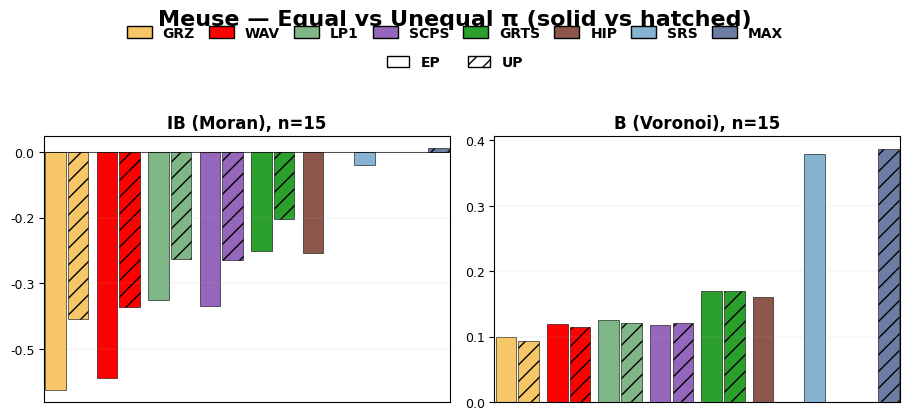

In [26]:
# meuse_n15_grz_bars.py
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# ---------- Data (n = 15) ----------
# Your method GRZ
GRZ_IB_EP   = -0.544167   # Moran (equal)
GRZ_IB_UP   = -0.382228   # Moran (unequal)
GRZ_B_EP    =  0.099278   # Voronoi/B (equal)
GRZ_B_UP    =  0.093827   # Voronoi/B (unequal)

# Meuse table (read from the screenshot)
# IB (Moran), n=15
IB_EP = {   # equal π
    "WAV": -0.518, "LP1": -0.338, "SCPS": -0.351, "GRTS": -0.226, "HIP": -0.230, "SRS": -0.030
}
IB_UP = {   # unequal π
    "WAV": -0.354, "LP1": -0.244, "SCPS": -0.247, "GRTS": -0.153, "MAX":  0.009
}

# B (Voronoi), n=15
B_EP  = {   # equal π
    "WAV": 0.119, "LP1": 0.125, "SCPS": 0.118, "GRTS": 0.170, "HIP": 0.160, "SRS": 0.379
}
B_UP  = {   # unequal π
    "WAV": 0.115, "LP1": 0.121, "SCPS": 0.120, "GRTS": 0.170, "MAX": 0.387
}

# Inject GRZ
IB_EP["GRZ"] = GRZ_IB_EP
IB_UP["GRZ"] = GRZ_IB_UP
B_EP["GRZ"]  = GRZ_B_EP
B_UP["GRZ"]  = GRZ_B_UP

# ---------- Plot config ----------
# Strict method order across both panels (missing entries will be left blank)
METHODS = ["GRZ", "WAV", "LP1", "SCPS", "GRTS", "HIP", "SRS", "MAX"]

# Colors (same scheme you’ve been using – WAV is red, pairs close in hue)
COLOR_MAP = {
    "GRZ": "#F6C667",  # soft amber
    "nMC": "#F4A259",  # not used here, kept for consistency
    "WAV": "#FF0000",
    "LP1": "#7FB685",
    "MAX": "#6C7CA2",
    "SRS": "#86B3D1",
    "HIP": "#8C564B",
    "SCPS": "#9467BD",
    "GRTS": "#2CA02C",
}

BAR_WIDTH = 0.40          # width of each bar (EP vs UP)
BAR_SEP   = 0.04          # small separation between EP and UP at same method
HIDE_X_LABELS = True
SAVE = True
OUT = Path("meuse_n15_grz_IB_B.png")

def aligned(measure_ep: dict, measure_up: dict, methods: list[str]):
    """Return two arrays aligned to 'methods' with NaN for missing values."""
    v_ep  = np.array([measure_ep.get(m, np.nan) for m in methods], dtype=float)
    v_up  = np.array([measure_up.get(m, np.nan) for m in methods], dtype=float)
    return v_ep, v_up

def plot_two_panels():
    fig, axs = plt.subplots(1, 2, figsize=(9.2, 4.2), sharey=False, constrained_layout=False)
    fig.subplots_adjust(top=0.78, wspace=0.25)

    # Top legends (methods + π)
    # Method legend (colored patches)
    method_patches = [
        mpatches.Patch(facecolor=COLOR_MAP.get(m, "#999999"), edgecolor="black", label=m)
        for m in METHODS
    ]
    fig.legend(
        handles=method_patches, loc="upper center", bbox_to_anchor=(0.50, 0.98),
        ncol=min(8, len(method_patches)), frameon=False,
        fontsize=12, handlelength=1.8, handleheight=0.9,
        columnspacing=1.0, labelspacing=0.4, prop={"weight": "bold"}
    )
    # π legend (hatch)
    pi_patches = [
        mpatches.Patch(facecolor="white", edgecolor="black", hatch="",  label="EP"),
        mpatches.Patch(facecolor="white", edgecolor="black", hatch="//", label="UP"),
    ]
    fig.legend(
        handles=pi_patches, loc="upper center", bbox_to_anchor=(0.50, 0.90),
        ncol=2, frameon=False, fontsize=12, handlelength=1.6, handleheight=0.9,
        borderaxespad=0.2, prop={"weight": "bold"}
    )

    # X positions
    x = np.arange(len(METHODS))
    x_ep  = x - (BAR_WIDTH/2 + BAR_SEP/2)
    x_up  = x + (BAR_WIDTH/2 + BAR_SEP/2)
    cols  = [COLOR_MAP.get(m, "#999999") for m in METHODS]

    # ---------- Left: IB (Moran) ----------
    vals_ep, vals_up = aligned(IB_EP, IB_UP, METHODS)
    ax = axs[0]
    ax.axhline(0, color="black", lw=0.7, alpha=0.7)
    ax.grid(axis="y", lw=0.3, alpha=0.4)
    ax.bar(x_ep, vals_ep, width=BAR_WIDTH, color=cols, hatch="",  edgecolor="black", linewidth=0.4)
    ax.bar(x_up, vals_up, width=BAR_WIDTH, color=cols, hatch="//", edgecolor="black", linewidth=0.4)
    ax.set_title("IB (Moran), n=15", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.tick_params(axis="y", labelsize=9)

    if HIDE_X_LABELS:
        ax.set_xticks([])
    else:
        ax.set_xticks(x)
        ax.set_xticklabels(METHODS, rotation=45, ha="right")

    pad = BAR_WIDTH + BAR_SEP
    ax.set_xlim(-pad, len(METHODS)-1+pad)

    # ---------- Right: B (Voronoi) ----------
    vals_ep, vals_up = aligned(B_EP, B_UP, METHODS)
    ax = axs[1]
    ax.axhline(0, color="black", lw=0.7, alpha=0.7)
    ax.grid(axis="y", lw=0.3, alpha=0.4)
    ax.bar(x_ep, vals_ep, width=BAR_WIDTH, color=cols, hatch="",  edgecolor="black", linewidth=0.4)
    ax.bar(x_up, vals_up, width=BAR_WIDTH, color=cols, hatch="//", edgecolor="black", linewidth=0.4)
    ax.set_title("B (Voronoi), n=15", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
    ax.tick_params(axis="y", labelsize=9)

    if HIDE_X_LABELS:
        ax.set_xticks([])
    else:
        ax.set_xticks(x)
        ax.set_xticklabels(METHODS, rotation=45, ha="right")

    ax.set_xlim(-pad, len(METHODS)-1+pad)

    fig.suptitle("Meuse — Equal vs Unequal π (solid vs hatched)", fontsize=16, y=0.99, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.86])

    if SAVE:
        fig.savefig(OUT, dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    plot_two_panels()


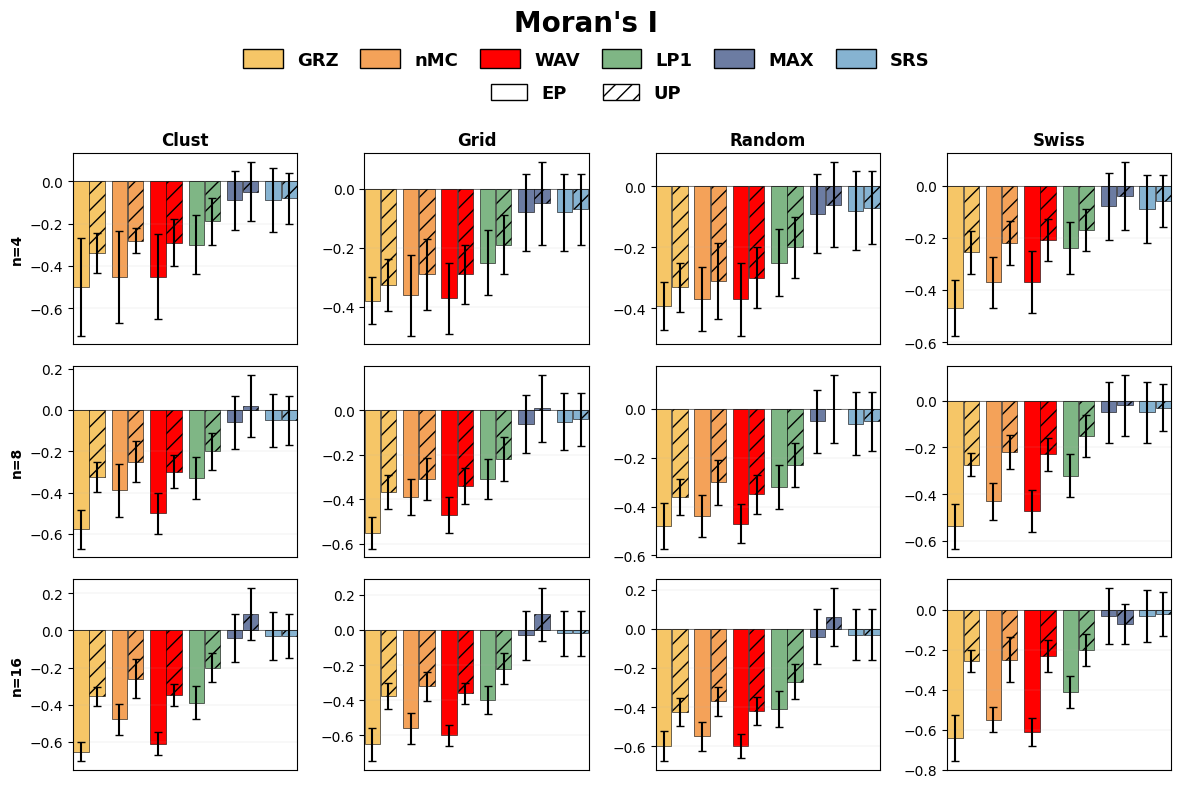

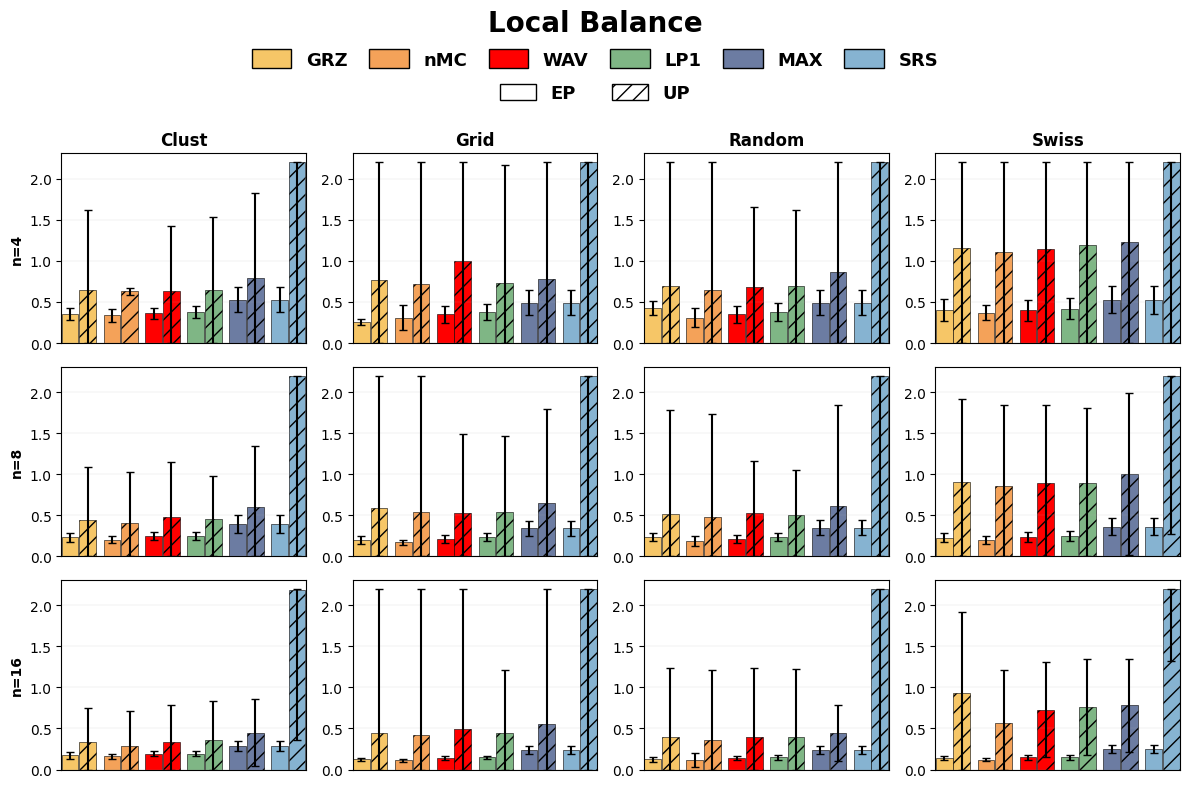

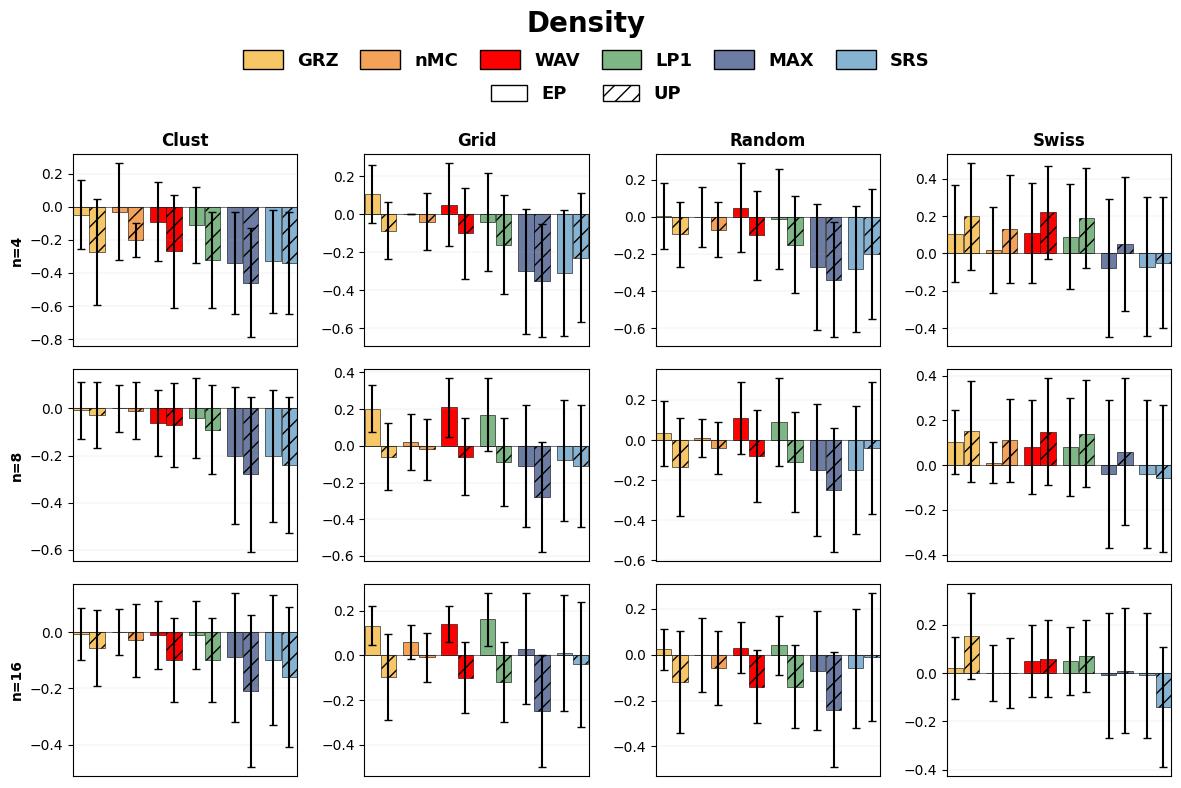

In [81]:
# paper_bars_grid.py
# 3 publication-ready bar charts with error bars:
#   Measures: I (Moran's I), L (Local Balance), D (Density)
#   Each figure mixes π=eq and π=uneq inside every subplot (hatched vs solid)
#   Layout per figure: 3 rows (n=4,8,16) × 4 cols (Clust, Grid, Random, Swiss)
# Rules:
#   - GRZ shown ONLY for Moran's I
#   - Consistent, custom colors by method (LP1≈LP2, MAX≈SRS, WAV near BnM/GRZ)
#   - Legend on top; x-axis method labels hidden for a clean look

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------- Paths ----------
CSV = Path("/home/divar/projects/graphical-sampling/simulation_results/Final_Results_4_Popu_Final_corrected.csv")
OUTDIR = Path("/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
MEASURES = [("I", "Moran's I"), ("L", "Local Balance"), ("D", "Density")]
POPUS = [("clust", "Clust"), ("grid", "Grid"), ("random", "Random"), ("swiss", "Swiss")]
NS = [4, 8, 16]

# Display settings
HIDE_X_LABELS = True
SHOW_GRZ_ONLY_FOR_I = True

# Side-by-side bar sizing (prevents overlap)
BAR_WIDTH = 0.40   # width of each (eq/uneq) bar
BAR_SEP   = 0.02   # gap between eq and uneq at the same method
# put this near the top with other config
Y_MAX = 2.2

# Colors by method (consistent everywhere)
COLOR_MAP = {
    "nMC": "#9467BD",  # alias for baseline
    "GRZ": "#4EA5FF",  # strong blue
    "WAV": "#FF0000",
    "LP1": "#2E8B57",  # greens (close)
    "MAX": "#E07A00",  # oranges (close)
    "SRS": "#FFAA33",
}

COLOR_MAP = {
    "nMC": "#1B3A6F",  # deep navy
    "GRZ": "#2F80ED",  # royal blue
    "WAV": "#FF0000",  # red
    "LP1": "#2E8B57",  # green
    "MAX": "#E67E22",  # burnt orange
    "SRS": "#FFB000",  # amber
}

COLOR_MAP = {
    "nMC": "#004488",  # dark blue
    "GRZ": "#66CCEE",  # sky blue
    "WAV": "#FF0000",  # red
    "LP1": "#228833",  # green
    "MAX": "#EE7733",  # orange
    "SRS": "#CCBB44",  # yellow-amber
}

COLOR_MAP = {
    "MAX": "#6C7CA2",  # pastel indigo
    "SRS": "#86B3D1",  # pastel blue
    "WAV": "#FF0000",  # red
    "LP1": "#7FB685",  # pastel green
    "nMC": "#F4A259",  # soft orange
    "GRZ": "#F6C667",  # soft amber
}



_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
def fallback_color(i: int) -> str:
    return _cycle[i % len(_cycle)]

# ---------- Data loading ----------
def load_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # remove LP2 everywhere (case-insensitive), no CSV change needed
    df = df[~df["Method"].str.contains(r"^lp2$", case=False, na=False)].copy()

    # normalize names
    if "Popu" in df.columns:
        df["Popu"] = df["Popu"].astype(str).str.lower().replace({"cluster": "clust"})
    if "pi" in df.columns:
        df["pi"] = df["pi"].astype(str).str.lower().replace(
            {"equal": "eq", "uneq": "uneq", "unequal": "uneq", "uequal": "uneq"}
        )

    # Some files use n vs N; standardize to 'n'
    if "N" in df.columns and "n" not in df.columns:
        df = df.rename(columns={"N": "n"})
    df["n"] = pd.to_numeric(df["n"], errors="coerce").astype("Int64")

    df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
    df["std"]  = pd.to_numeric(df["std"],  errors="coerce")

    # Keep only I/L/D (ignore Voronoi)
    df = df[df["Measure"].isin(["I", "L", "D"])]

    # In-memory renames to unify method labels
    df["Method"] = df["Method"].astype(str).replace({
        "B": "BnM",
        "BNM": "BnM",
    })

    return df.dropna(subset=["n", "mean", "std", "Popu", "pi", "Method", "Measure"]).copy()

# Preferred method order per measure (strict order kept even if some are missing)
METHOD_ORDER_BY_MEASURE = {
    "I": ["GRZ", "nMC", "WAV", "LP1", "MAX", "SRS"],
    "L": ["GRZ","nMC", "WAV", "LP1", "MAX", "SRS"], 
    "D": ["GRZ","nMC", "WAV", "LP1", "MAX", "SRS"], 
}

def methods_for_measure(df_measure: pd.DataFrame, measure_code: str) -> list[str]:
    """Return the method order for an entire measure (union across eq/uneq),
       respecting METHOD_ORDER_BY_MEASURE exactly."""
    pref = METHOD_ORDER_BY_MEASURE.get(measure_code, [])
    present_all = df_measure["Method"].astype(str).unique().tolist()

    # Keep the preferred order exactly, but include only those present
    ordered = [m for m in pref if m in present_all]

    # Append any extra (unexpected) methods in alpha order, but after our preferred list
    extras = sorted([m for m in present_all if m not in ordered])
    ordered += extras

    # Enforce GRZ visibility rule
    # if SHOW_GRZ_ONLY_FOR_I and measure_code != "I":
    #     ordered = [m for m in ordered if m != "GRZ"]

    return ordered

def build_series_for_methods(sub: pd.DataFrame, methods: list[str]):
    """Return arrays aligned to 'methods' for mean/std; NaNs for missing."""
    m2 = sub.set_index(sub["Method"].astype(str))[["mean","std"]].astype(float)

    # clip raw mean/std to Y_MAX
    m2 = m2.clip(upper=Y_MAX)
    # std must be non-negative
    m2["std"] = m2["std"].clip(lower=0)

    vals = np.array([m2.loc[m, "mean"] if m in m2.index else np.nan for m in methods], dtype=float)
    errs = np.array([m2.loc[m, "std"]  if m in m2.index else np.nan for m in methods], dtype=float)

    return vals, errs


def yerr_for_measure(measure_code: str, vals: np.ndarray, errs: np.ndarray):
    """Asymmetric yerr for Local Balance clipped at 0; symmetric otherwise.
       Also cap the *upper* error so mean+err never exceeds Y_MAX."""
    # no error bars for missing values
    errs = np.where(np.isnan(vals), 0.0, errs)
    errs = np.clip(errs, 0, None)  # std cannot be negative

    # cap the upper tail so bars+caps never exceed Y_MAX
    upper_cap = np.maximum(0.0, Y_MAX - np.nan_to_num(vals, nan=Y_MAX))
    err_up = np.minimum(errs, upper_cap)

    if measure_code == "L":
        # lower side must not dip below 0
        lower = np.minimum(errs, np.maximum(vals, 0.0))
        return np.vstack([lower, err_up])   # asymmetric
    else:
        return err_up  # symmetric 1D (already upper-capped)


# ---------- Plotting ----------
def plot_measure_combined(measure_code: str, measure_name: str, df: pd.DataFrame):
    """One figure per measure; each subplot mixes eq & uneq as side-by-side hatched bars."""
    dfx = df[df["Measure"] == measure_code].copy()
    if dfx.empty:
        return

    # Global method order for this measure (kept everywhere)
    methods = methods_for_measure(dfx, measure_code)
    if not methods:
        return
    legend_methods = methods[:]  # for the top legend

    # Make room at the top for legend + title
    fig, axs = plt.subplots(
        nrows=len(NS), ncols=len(POPUS),
        # figsize=(12, 8), sharey=True, constrained_layout=False
        figsize=(12, 8), sharey=False, constrained_layout=False
    )
    fig.subplots_adjust(top=0.80)  # ~20% headroom

    x = np.arange(len(methods))
    cols = [COLOR_MAP.get(m, fallback_color(i)) for i, m in enumerate(methods)]

    # Precompute offset centers to avoid overlap
    x_eq   = x - (BAR_WIDTH/2 + BAR_SEP/2)
    x_uneq = x + (BAR_WIDTH/2 + BAR_SEP/2)

    for r, n in enumerate(NS):
        for c, (pop_code, pop_label) in enumerate(POPUS):
            ax = axs[r, c]
            sub_eq   = dfx[(dfx["n"] == n) & (dfx["Popu"] == pop_code) & (dfx["pi"] == "eq")]
            sub_uneq = dfx[(dfx["n"] == n) & (dfx["Popu"] == pop_code) & (dfx["pi"] == "uneq")]

            ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
            ax.grid(axis="y", linewidth=0.3, alpha=0.4)

            # Build method-aligned arrays for both pi
            vals_eq,   errs_eq   = build_series_for_methods(sub_eq, methods)
            vals_uneq, errs_uneq = build_series_for_methods(sub_uneq, methods)

            # yerr (asymmetric for L)
            yerr_eq   = yerr_for_measure(measure_code, vals_eq, errs_eq)
            yerr_uneq = yerr_for_measure(measure_code, vals_uneq, errs_uneq)

            # Bars: same colors by method; hatch distinguishes pi (no overlap)
            ax.bar(x_eq,   vals_eq,   width=BAR_WIDTH, yerr=yerr_eq,   color=cols, hatch="",
                   capsize=3, edgecolor="black", linewidth=0.4)
            ax.bar(x_uneq, vals_uneq, width=BAR_WIDTH, yerr=yerr_uneq, color=cols, hatch="//",
                   capsize=3, edgecolor="black", linewidth=0.4)

            # Keep Local Balance axis non-negative
            if measure_code == "L":
                ymin, ymax = ax.get_ylim()
                ax.set_ylim(bottom=0, top=ymax)

            # x-axis labels
            if HIDE_X_LABELS:
                ax.set_xticks([])
                ax.tick_params(axis="x", length=0)
            else:
                ax.set_xticks(x)
                ax.set_xticklabels(methods, rotation=45, ha="right")

            # Titles/labels
            if r == 0:
                    ax.set_title(pop_label, fontweight="bold")
            if c == 0:
                ax.set_ylabel(f"n={n}", fontweight="bold")

            # breathing room so caps don't clip
            pad = BAR_WIDTH + BAR_SEP
            ax.set_xlim(-pad, len(methods) - 1 + pad)

    # Legend for methods (top, fixed order)
    handles_methods = [
        plt.Line2D([0], [0], lw=6, color=COLOR_MAP.get(m, fallback_color(i)), label=m)
        for i, m in enumerate(legend_methods)
    ]
    # --- METHOD legend: bigger colored rectangles, centered at top ---
    method_patches = [
        mpatches.Patch(facecolor=COLOR_MAP.get(m, fallback_color(i)),
                    edgecolor="black", label=m)
        for i, m in enumerate(legend_methods)
    ]
    fig.legend(handles=method_patches,
            loc="upper center", bbox_to_anchor=(0.5, 0.95),
            ncol=min(8, len(method_patches)), frameon=False,
            fontsize=15, handlelength=2.2, handleheight=1.2,
            columnspacing=1.2, labelspacing=0.6,
            prop={"weight": "bold", "size": 13})

    # --- π legend: move and enlarge ---
    pi_patches = [
        mpatches.Patch(facecolor="white", edgecolor="black", hatch="",  label="EP"),
        mpatches.Patch(facecolor="white", edgecolor="black", hatch="//", label="UP"),
    ]
    fig.legend(handles=pi_patches, loc="upper center", 
               bbox_to_anchor=(0.5, 0.90), ncol=2, frameon=False, 
               fontsize=15, handlelength=2.0, handleheight=1.0, borderaxespad=0.2,
               prop={"weight": "bold", "size": 13})


    # --- Title: larger and slightly lower so it doesn't collide with legends ---
    fig.suptitle(f"{measure_name}",
                fontsize=20, y=0.98, fontweight="bold")

    # keep space for legends/title
    fig.tight_layout(rect=[0, 0, 1, 0.90])


    out = OUTDIR / f"{measure_code}_combined_grid_bars.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")

def main():
    df = load_df(CSV)
    for code, name in MEASURES:
        plot_measure_combined(code, name, df)
    plt.show()

if __name__ == "__main__":
    main()


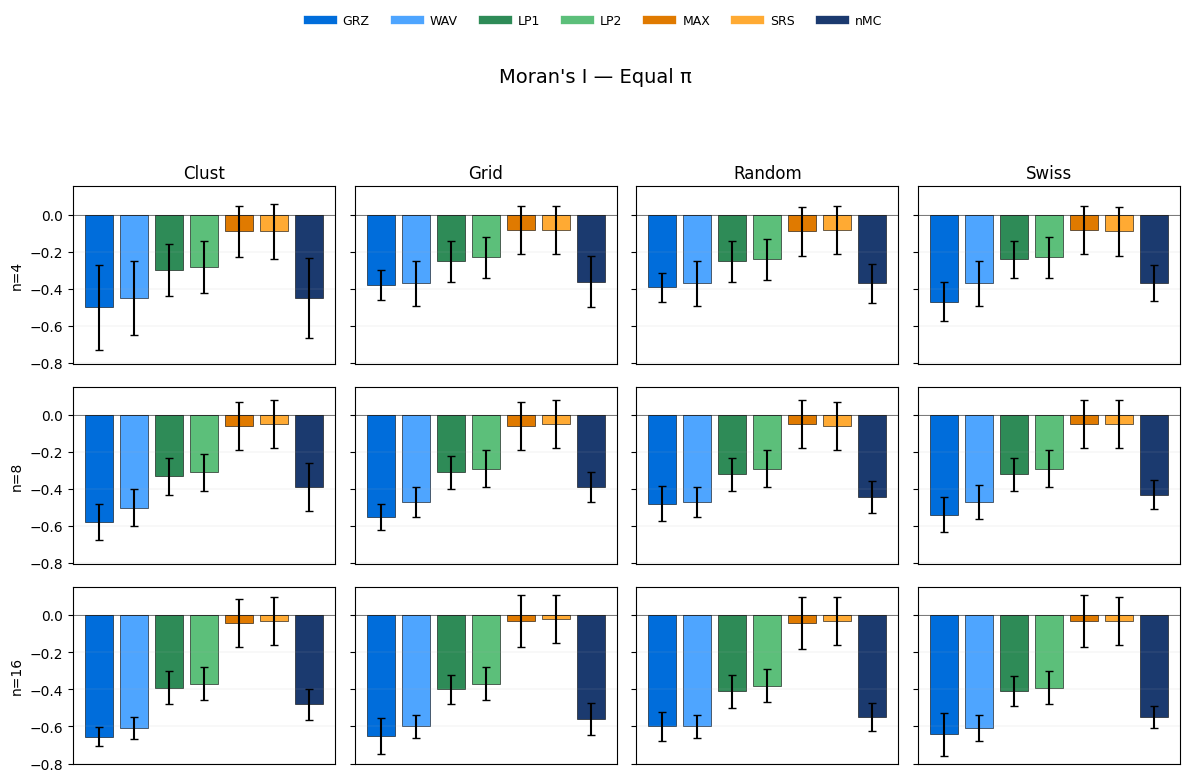

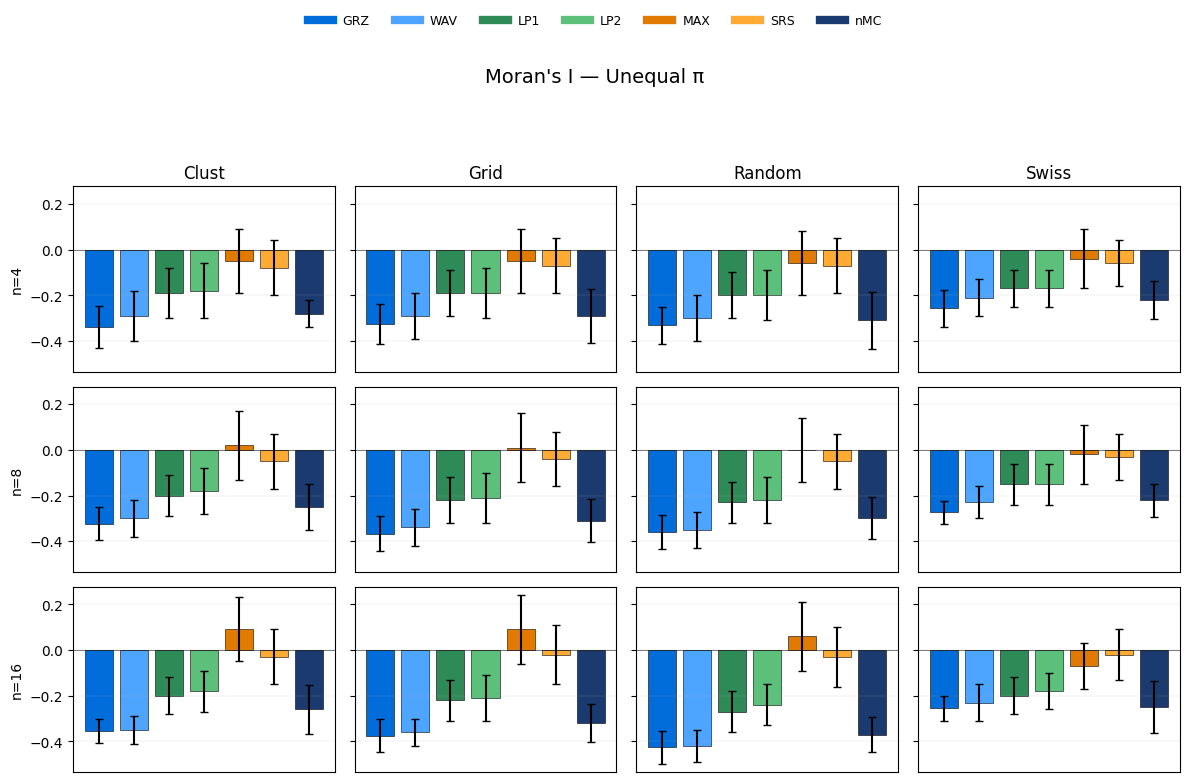

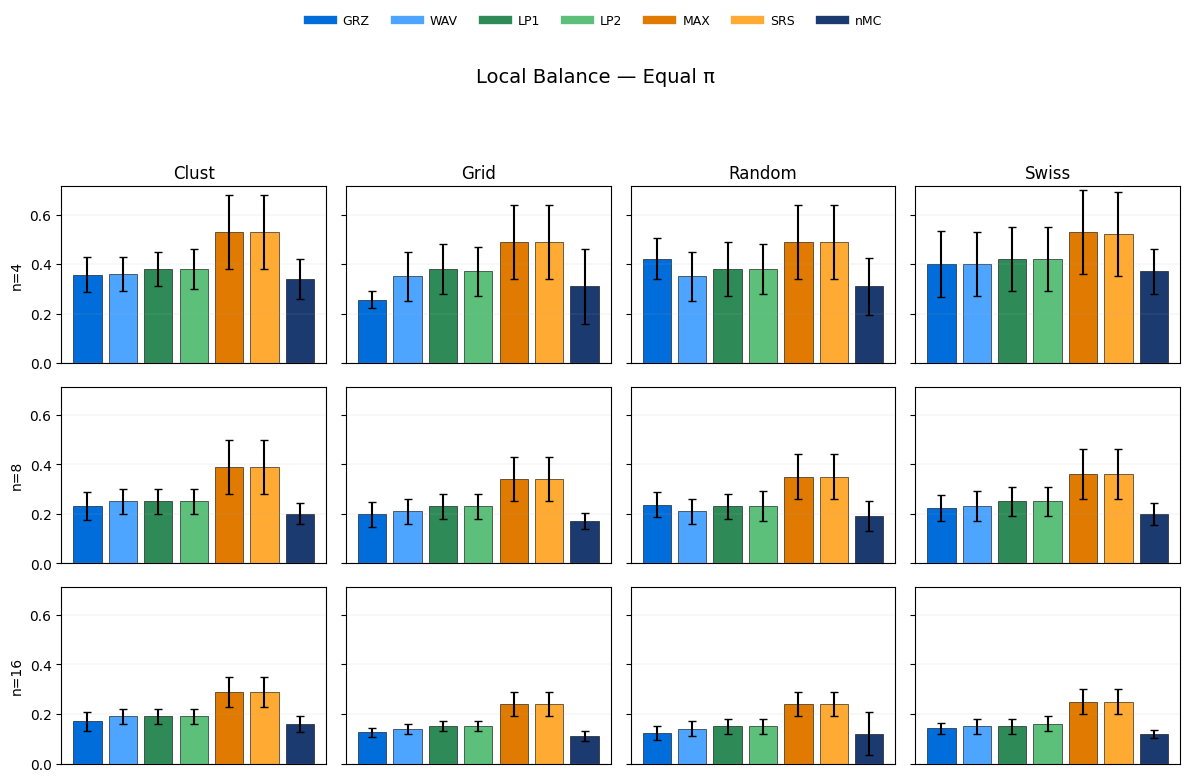

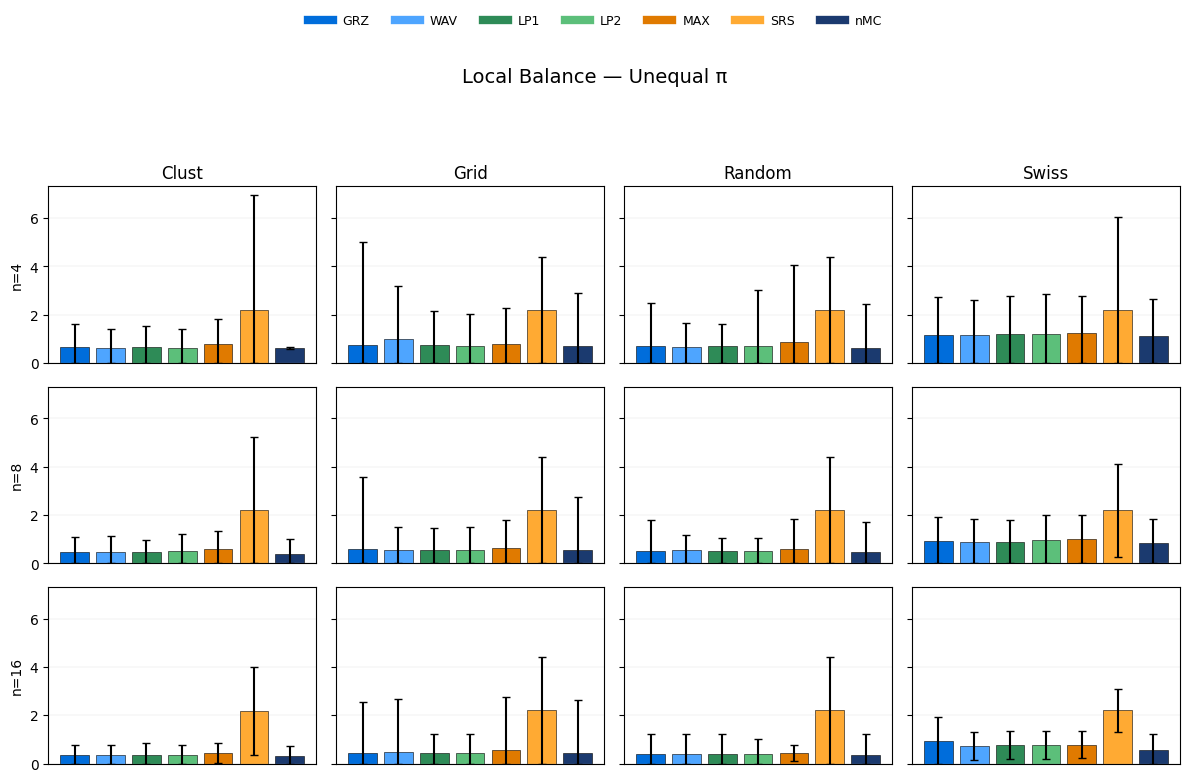

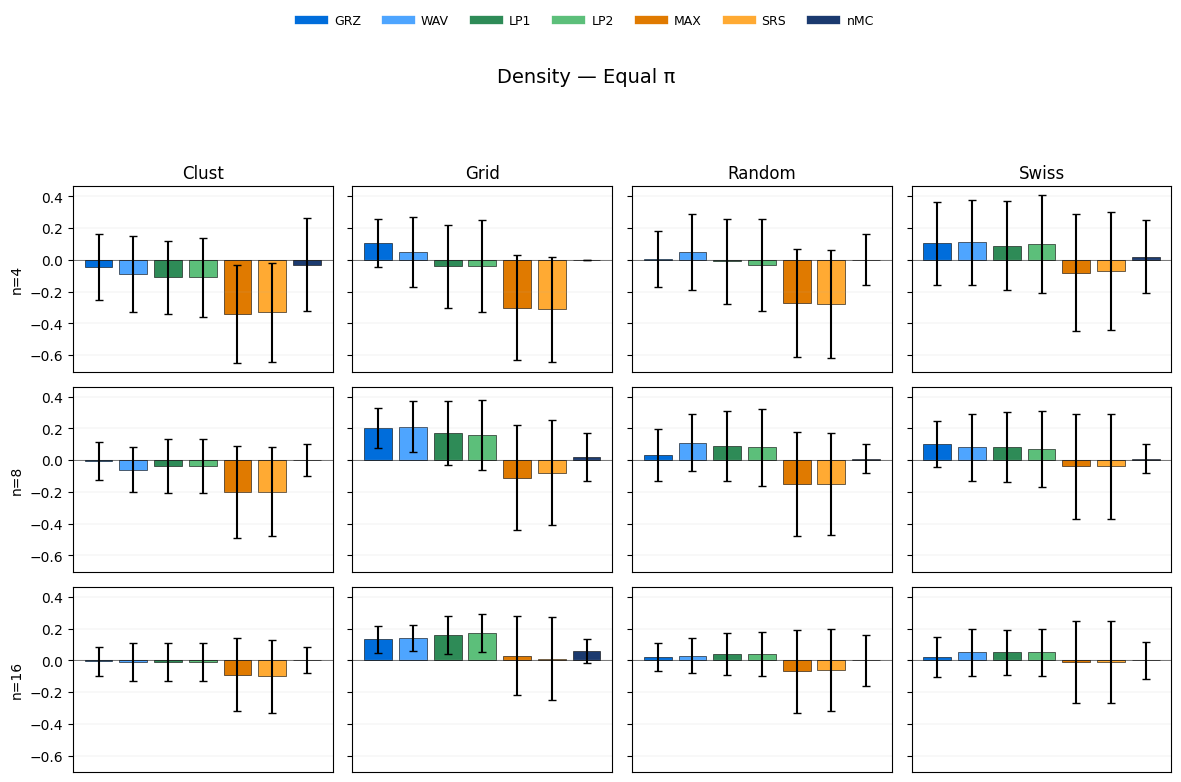

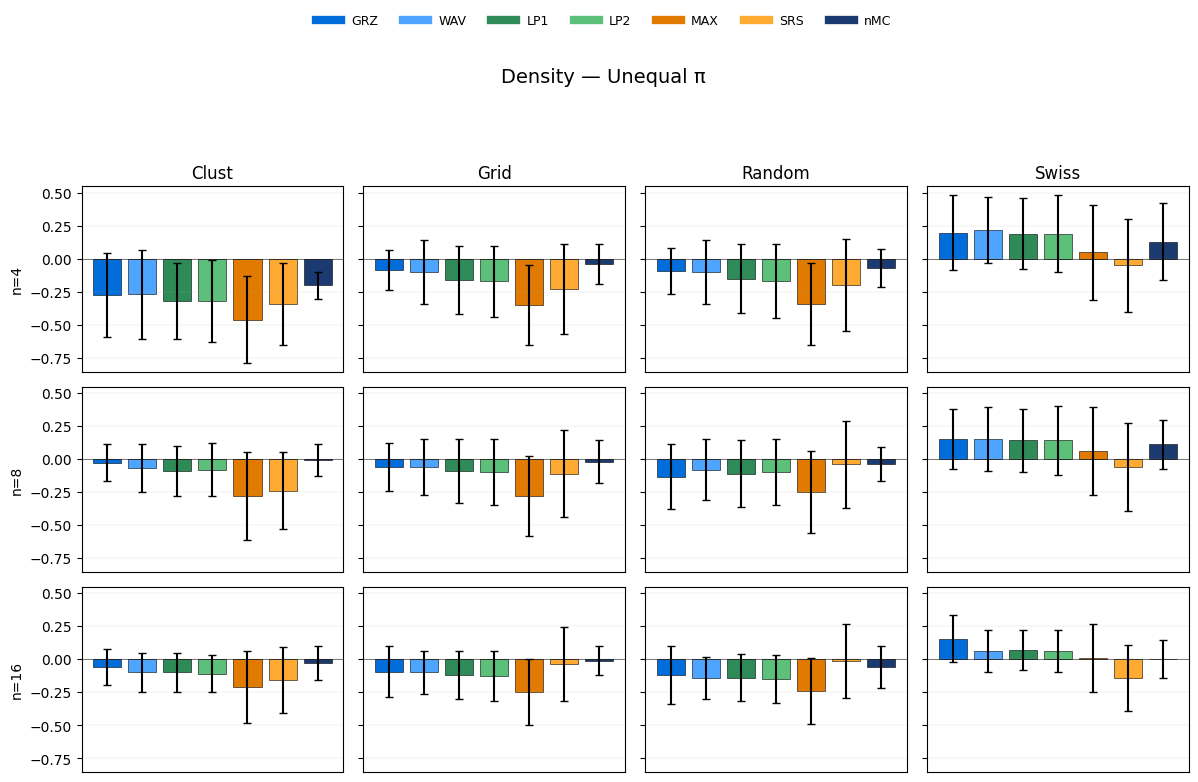

In [76]:
# paper_bars_grid.py
# 6 publication-ready bar charts with error bars:
#   Measures: I (Moran's I), L (Local Balance), D (Density)
#   π: eq, uneq
#   Layout per figure: 3 rows (n=4,8,16) × 4 cols (Clust, Grid, Random, Swiss)
# Rules:
#   - GRZ is shown ONLY for Moran's I
#   - Consistent, custom colors by method (LP1≈LP2, MAX≈SRS, WAV near BnM/GRZ)
#   - Legend on top; x-axis method labels hidden for a clean look

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Paths ----------
CSV = Path("/home/divar/projects/graphical-sampling/simulation_results/Final_Results_4_Popu_Final_corrected.csv")
OUTDIR = Path("/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
MEASURES = [("I", "Moran's I"), ("L", "Local Balance"), ("D", "Density")]
PIS = [("eq", "Equal π"), ("uneq", "Unequal π")]
POPUS = [("clust", "Clust"), ("grid", "Grid"), ("random", "Random"), ("swiss", "Swiss")]
NS = [4, 8, 16]

# Hide x-axis labels since legend carries the method names
HIDE_X_LABELS = True
# Show GRZ only for Moran's I
SHOW_GRZ_ONLY_FOR_I = True

# Custom colors by method (consistent across all figures)
COLOR_MAP = {
    # Baseline cluster near GRZ/WAV (blues)
    "BnM": "#1B3A6F",  # deep navy
    "nMC": "#1B3A6F",  # same as baseline alias
    "GRZ": "#006DDB",  # strong blue
    "WAV": "#4EA5FF",  # sky blue
    "wMC": "#4EA5FF",  # alias for WAV

    # Pairs with close hues
    "LP1": "#2E8B57",  # greens (close)
    "LP2": "#5CBF7A",

    "MAX": "#E07A00",  # oranges (close)
    "SRS": "#FFAA33",

    # Others (fallback set)
    "HIP": "#8C564B",
    "DAS": "#C49C94",
    "GRT": "#9467BD",
    "SPI": "#C5B0D5",
}
_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
def fallback_color(i: int) -> str:
    return _cycle[i % len(_cycle)]

# ---------- Data loading ----------
def load_df(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # normalize names
    if "Popu" in df.columns:
        df["Popu"] = df["Popu"].astype(str).str.lower().replace({"cluster": "clust"})
    if "pi" in df.columns:
        df["pi"] = df["pi"].astype(str).str.lower().replace(
            {"equal": "eq", "uneq": "uneq", "unequal": "uneq", "uequal": "uneq"}
        )

    # some files use n, others N; standardize to 'n'
    if "N" in df.columns and "n" not in df.columns:
        df = df.rename(columns={"N": "n"})
    df["n"] = pd.to_numeric(df["n"], errors="coerce").astype("Int64")

    df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
    df["std"]  = pd.to_numeric(df["std"],  errors="coerce")

    # keep only I/L/D (ignore Voronoi)
    df = df[df["Measure"].isin(["I", "L", "D"])]

    # optional in-memory renames to unify method labels
    df["Method"] = df["Method"].astype(str).replace({
        "B": "BnM",
        "BNM": "BnM",
    })

    return df.dropna(subset=["n", "mean", "std", "Popu", "pi", "Method", "Measure"]).copy()

# Per-measure preferred order (only those present are used)
METHOD_ORDER_BY_MEASURE = {
    "I": ["GRZ", "BnM", "WAV", "LP1", "LP2", "MAX", "SRS"],
    "L": ["GRZ", "BnM", "WAV", "LP1", "LP2", "MAX", "SRS"],
    "D": ["GRZ","BnM", "WAV", "LP1", "LP2", "MAX", "SRS"],
}

def methods_for_subset(sub: pd.DataFrame, measure_code: str) -> list[str]:
    pref = METHOD_ORDER_BY_MEASURE.get(measure_code, [])
    present_all = sub["Method"].astype(str).unique().tolist()

    ordered = [m for m in pref if m in present_all]
    extras = sorted([m for m in present_all if m not in ordered])
    ordered += extras

    # if SHOW_GRZ_ONLY_FOR_I and measure_code != "I":
    #     ordered = [m for m in ordered if m != "GRZ"]
    return ordered

# ---------- Plotting ----------
def plot_one(measure_code: str, measure_name: str, pi_code: str, pi_name: str, df: pd.DataFrame):
    dfx = df[(df["Measure"] == measure_code) & (df["pi"] == pi_code)].copy()
    if dfx.empty:
        return

    methods = methods_for_subset(dfx, measure_code)
    if not methods:
        return
    legend_methods = methods[:]  # define BEFORE using it

    # Make room at the top for legend + title
    fig, axs = plt.subplots(
        nrows=len(NS), ncols=len(POPUS),
        figsize=(12, 8), sharey=True, constrained_layout=False
    )
    fig.subplots_adjust(top=0.80)  # ~20% headroom

    for r, n in enumerate(NS):
        for c, (pop_code, pop_label) in enumerate(POPUS):
            ax = axs[r, c]
            sub = dfx[(dfx["n"] == n) & (dfx["Popu"] == pop_code)]
            ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
            ax.grid(axis="y", linewidth=0.3, alpha=0.4)

            if sub.empty:
                if r == 0:
                    ax.set_title(pop_label, fontweight="bold")
                if c == 0:
                    ax.set_ylabel(f"n={n}", fontweight="bold")
                ax.set_xticks([])
                ax.tick_params(axis="x", length=0)
                continue

            # Enforce method order
            present = [m for m in methods if m in set(sub["Method"].astype(str))]
            if not present:
                if r == 0:
                    ax.set_title(pop_label)
                if c == 0:
                    ax.set_ylabel(f"n={n}")
                ax.set_xticks([])
                ax.tick_params(axis="x", length=0)
                continue

            sub = sub.copy()
            sub["Method"] = pd.Categorical(sub["Method"].astype(str), categories=present, ordered=True)
            sub = sub.sort_values("Method")

            x = np.arange(len(sub))
            vals = sub["mean"].to_numpy()
            errs = sub["std"].to_numpy()
            meth = sub["Method"].astype(str).tolist()
            cols = [COLOR_MAP.get(m, fallback_color(i)) for i, m in enumerate(meth)]

            # Use asymmetric yerr for Local Balance so the lower bar never dips below 0
            if measure_code == "L":
                # ensure (vals - lower) >= 0  → lower = min(std, max(vals, 0))
                lower = np.minimum(errs, np.maximum(vals, 0))
                upper = errs
                yerr = np.vstack([lower, upper])   # shape (2, N)
            else:
                yerr = errs  # symmetric for I and D

            ax.bar(x, vals, yerr=yerr, color=cols, capsize=3,
                edgecolor="black", linewidth=0.4)

            # Keep Local Balance axis non-negative (nice-to-have)
            if measure_code == "L":
                ymin, ymax = ax.get_ylim()
                ax.set_ylim(bottom=0, top=ymax)

            if HIDE_X_LABELS:
                ax.set_xticks([])
                ax.tick_params(axis="x", length=0)
            else:
                ax.set_xticks(x)
                ax.set_xticklabels(meth, rotation=45, ha="right")

            if r == 0:
                ax.set_title(pop_label)
            if c == 0:
                ax.set_ylabel(f"n={n}")

    # Title below the legend; legend at the very top
    handles = [
        plt.Line2D([0], [0], lw=6, color=COLOR_MAP.get(m, fallback_color(i)), label=m)
        for i, m in enumerate(legend_methods)
    ]
    fig.legend(handles, [h.get_label() for h in handles],
               loc="upper center", bbox_to_anchor=(0.5, 0.98),
               ncol=min(8, len(handles)), frameon=False, fontsize=9)

    fig.suptitle(f"{measure_name} — {pi_name}", fontsize=14, y=0.90)
    fig.tight_layout(rect=[0, 0, 1, 0.84])  # keep the top margin intact

    out = OUTDIR / f"{measure_code}_{pi_code}_grid_bars.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")

def main():
    df = load_df(CSV)
    for code, name in MEASURES:
        for pcode, pname in PIS:
            plot_one(code, name, pcode, pname, df)
    # Show immediately in VS Code
    plt.show()

if __name__ == "__main__":
    main()


/tmp/ipykernel_584948/3579933159.py:55: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.80)
/tmp/ipykernel_584948/3579933159.py:55: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.80)
/tmp/ipykernel_584948/3579933159.py:55: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.80)
/tmp/ipykernel_584948/3579933159.py:55: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.80)
/tmp/ipykernel_584948/3579933159.py:55: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or 

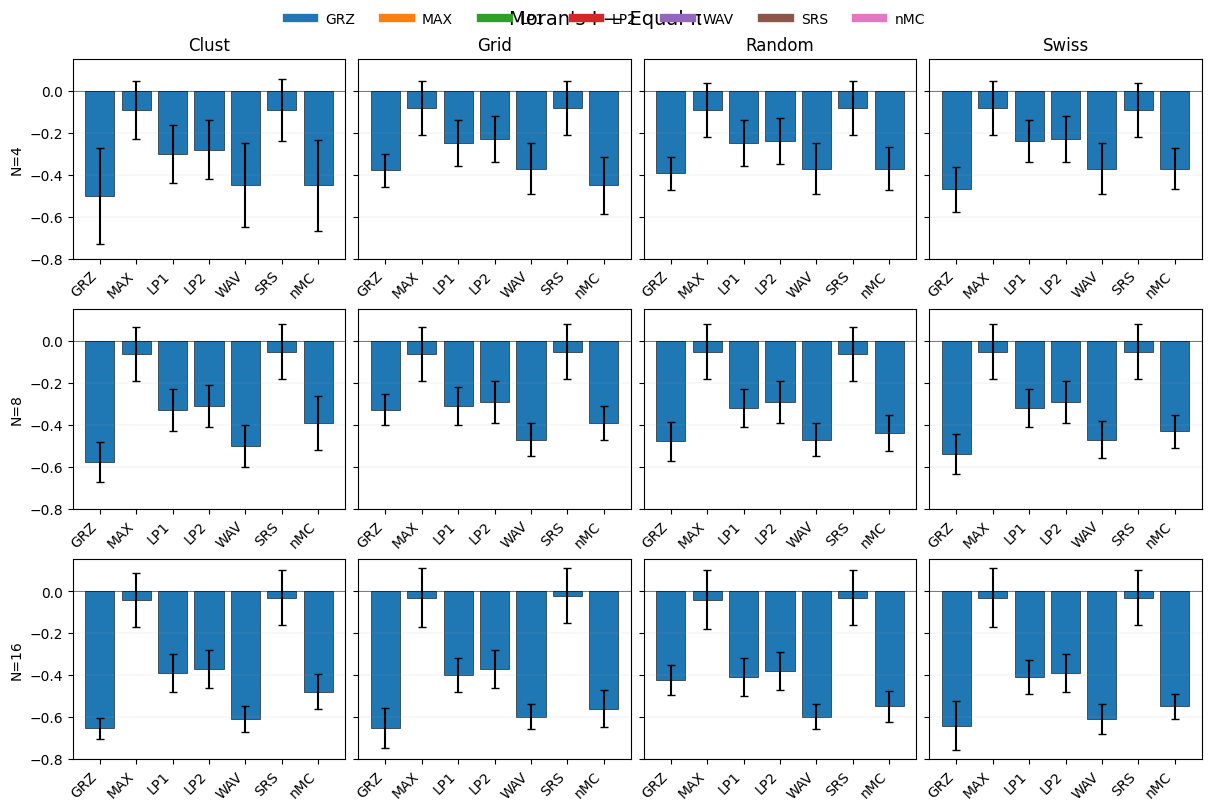

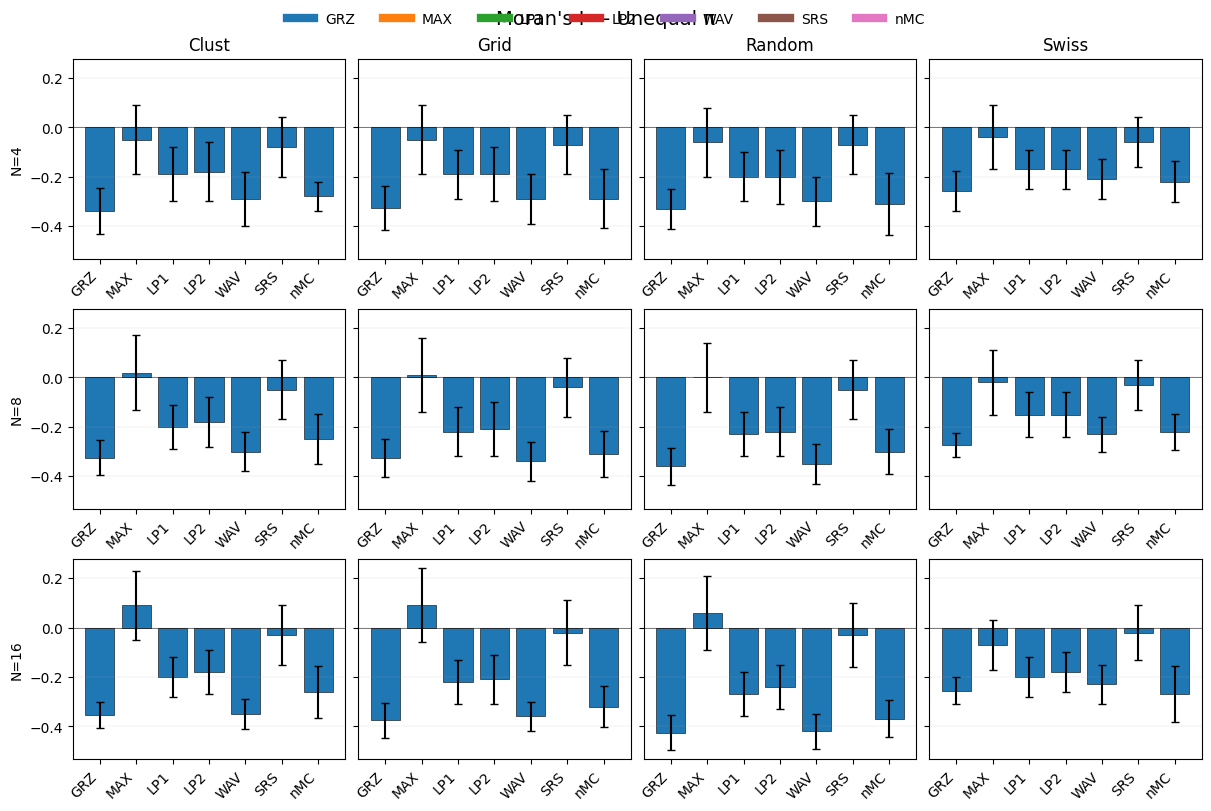

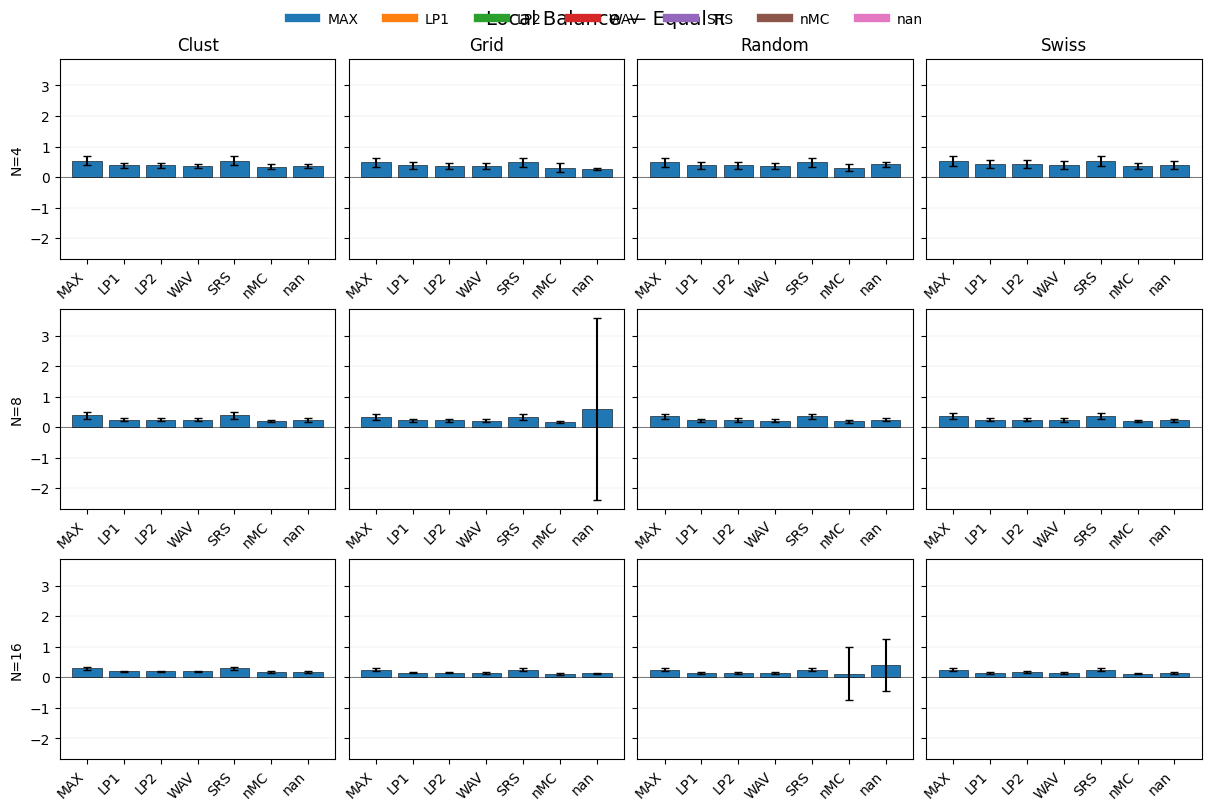

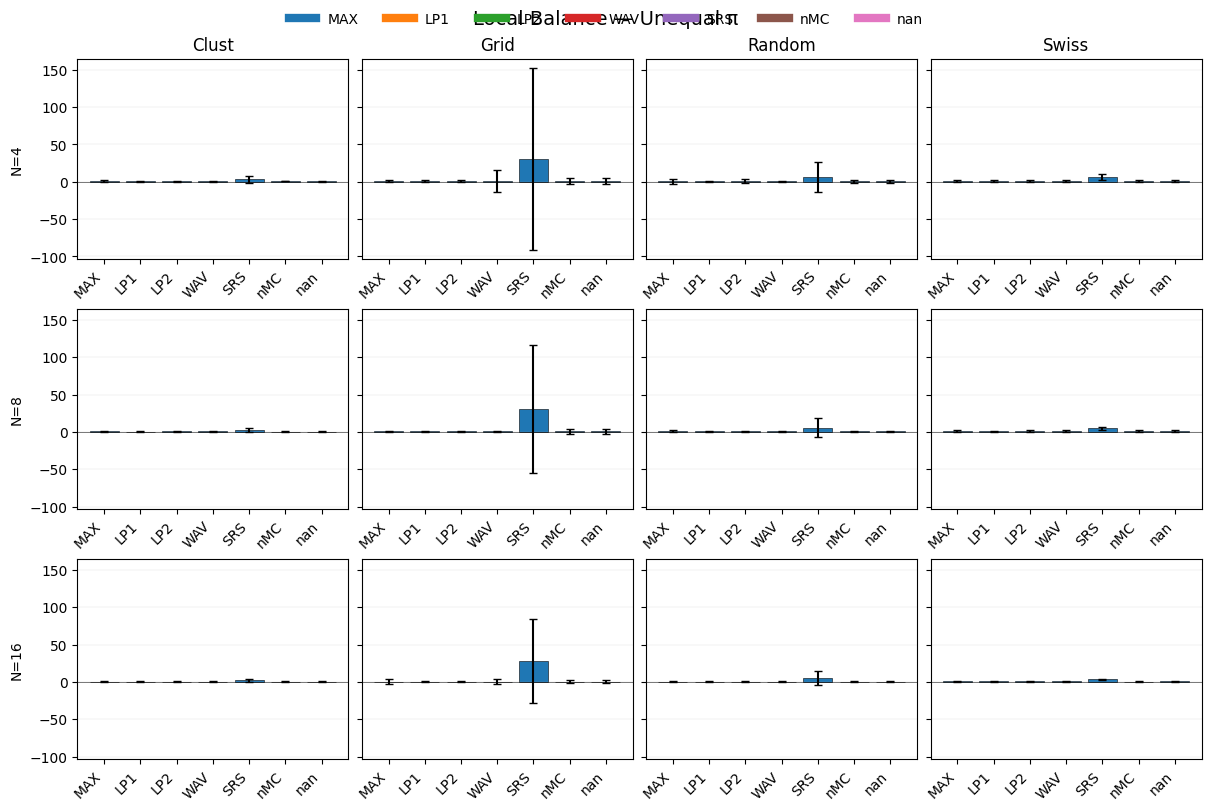

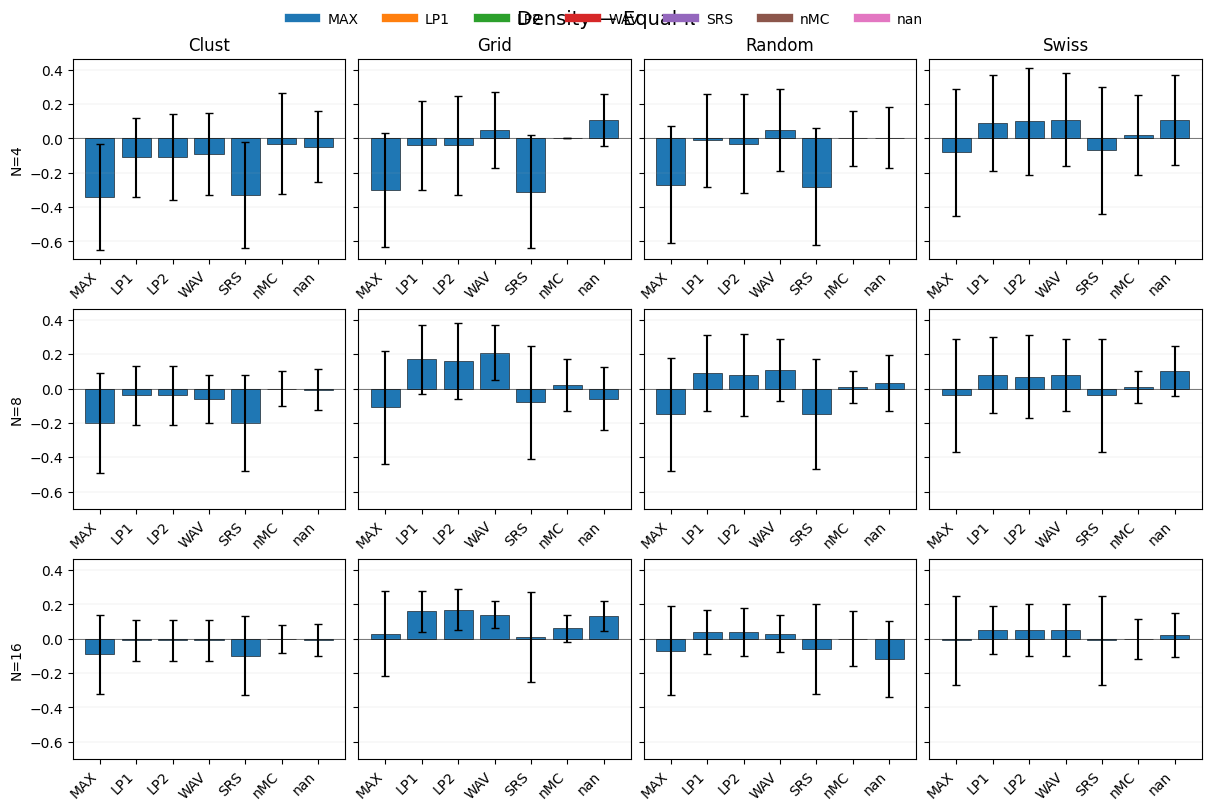

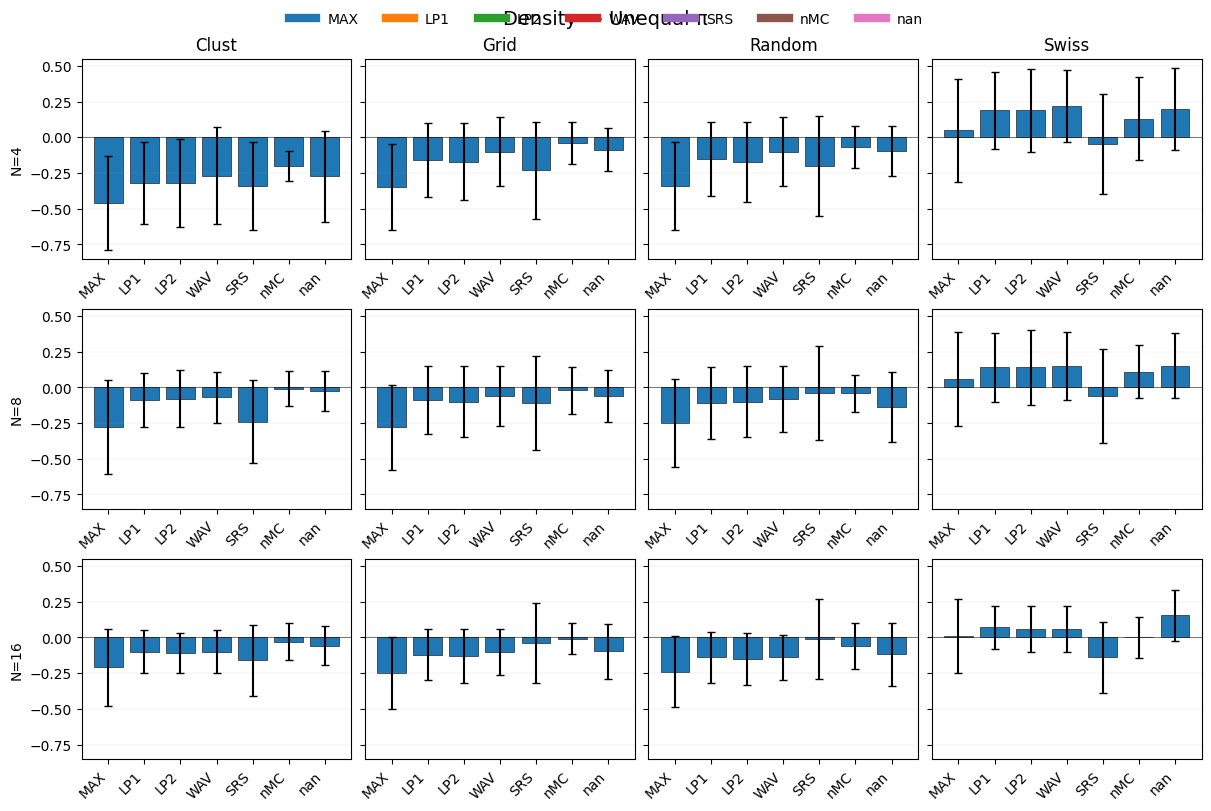

In [ ]:
# paper_bars_grid.py
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV = Path("/home/divar/projects/graphical-sampling/simulation_results/Final_Results_4_Popu_Final.csv")
OUTDIR = Path("/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final")
OUTDIR.mkdir(parents=True, exist_ok=True)


MEASURES = [("I", "Moran's I"), ("L", "Local Balance"), ("D", "Density")]
PIS = [("eq", "Equal π"), ("uneq", "Unequal π")]
POPUS = [("clust", "Clust"), ("grid", "Grid"), ("random", "Random"), ("swiss", "Swiss")]
NS = [4, 8, 16]

# Preferred method ordering; any others found will follow alphabetically
METHOD_ORDER = ["BnM", "GRZ", "MAX", "LP1", "LP2", "WAV", "SRS", "HIP", "DAS", "GRT", "SPI"]

def load_df(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["Popu"] = df["Popu"].astype(str).str.lower().replace({"cluster": "clust"})
    df["pi"] = df["pi"].astype(str).str.lower().replace(
        {"equal":"eq", "uneq":"uneq", "unequal":"uneq", "uequal":"uneq"}
    )
    df["N"] = pd.to_numeric(df["N"], errors="coerce").astype("Int64")
    df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
    df["std"]  = pd.to_numeric(df["std"], errors="coerce")
    return df.dropna(subset=["N","mean","std","Popu","pi","Method","Measure"]).copy()

def methods_for_subset(sub: pd.DataFrame, measure_code: str) -> list[str]:
    mset = sorted(sub["Method"].astype(str).unique())
    # Put our preferred order first
    ordered = [m for m in METHOD_ORDER if m in mset] + [m for m in mset if m not in METHOD_ORDER]
    # Show GRZ only for Moran's I
    if measure_code != "I":
        ordered = [m for m in ordered if m != "GRZ"]
    return ordered

def plot_one(measure_code: str, measure_name: str, pi_code: str, pi_name: str, df: pd.DataFrame):
    dfx = df[(df["Measure"]==measure_code) & (df["pi"]==pi_code)].copy()
    if dfx.empty:
        return

    methods = methods_for_subset(dfx, measure_code)
    if not methods:
        return

    fig, axs = plt.subplots(
        nrows=len(NS), ncols=len(POPUS),
        figsize=(12, 8),
        sharey=True, constrained_layout=True
    )
    fig.subplots_adjust(top=0.80)

    # Build legend handles only once
    legend_methods = []

    for r, N in enumerate(NS):
        for c, (pop_code, pop_label) in enumerate(POPUS):
            ax = axs[r, c]
            sub = dfx[(dfx["N"]==N) & (dfx["Popu"]==pop_code)]
            ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
            ax.grid(axis="y", linewidth=0.3, alpha=0.4)

            if sub.empty:
                ax.set_xticks([])
                if r == 0:
                    ax.set_title(pop_label)
                if c == 0:
                    ax.set_ylabel(f"N={N}")
                continue

            # Keep only methods present here (and enforce GRZ visibility rule)
            present = [m for m in methods if m in set(sub["Method"].astype(str))]
            if not present:
                ax.set_xticks([])
                if r == 0:
                    ax.set_title(pop_label)
                if c == 0:
                    ax.set_ylabel(f"N={N}")
                continue

            # Sort by our method order
            sub = sub.copy()
            sub["Method"] = pd.Categorical(sub["Method"].astype(str), categories=present, ordered=True)
            sub = sub.sort_values("Method")

            x = np.arange(len(sub))
            vals = sub["mean"].to_numpy()
            errs = sub["std"].to_numpy()

            bars = ax.bar(x, vals, yerr=errs, capsize=3, edgecolor="black", linewidth=0.4)
            ax.set_xticks(x)
            ax.set_xticklabels(sub["Method"].astype(str), rotation=45, ha="right")

            if r == 0:
                ax.set_title(pop_label)
            if c == 0:
                ax.set_ylabel(f"N={N}")

            # Record legend labels once from the first subplot
            if r == 0 and c == 0:
                legend_methods = sub["Method"].astype(str).tolist()

    # Figure title + shared legend
    fig.suptitle(f"{measure_name} — {pi_name}", fontsize=14)
    if legend_methods:
        # Create dummy lines to show a clean legend
        handles = [plt.Line2D([0],[0], lw=6, color=plt.rcParams["axes.prop_cycle"].by_key()["color"][i % 10],
                              label=legend_methods[i]) for i in range(len(legend_methods))]
        fig.legend(handles, legend_methods, loc="upper center", ncol=min(8, len(legend_methods)), frameon=False)

    # Save & show
    out = OUTDIR / f"{measure_code}_{pi_code}_grid_bars.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")

def main():
    df = load_df(CSV)
    for code, name in MEASURES:
        for pcode, pname in PIS:
            plot_one(code, name, pcode, pname, df)

    # show immediately in VS Code
    plt.show()

if __name__ == "__main__":
    main()


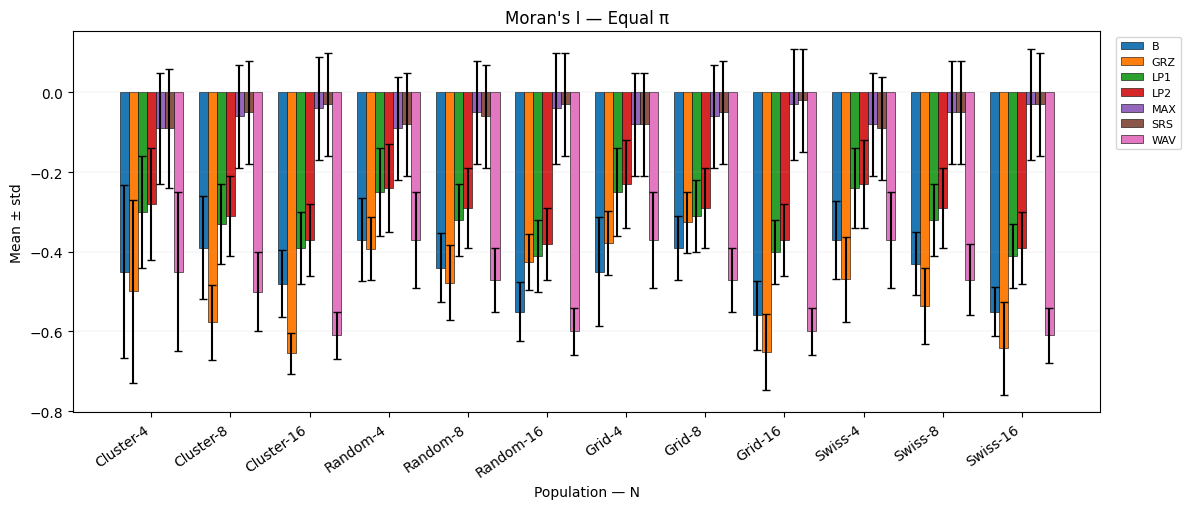

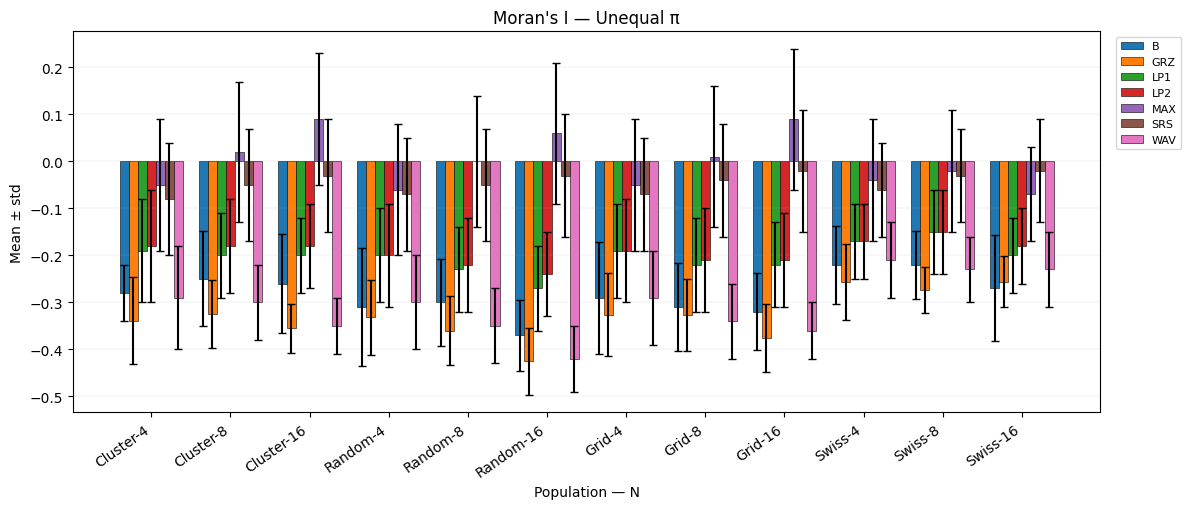

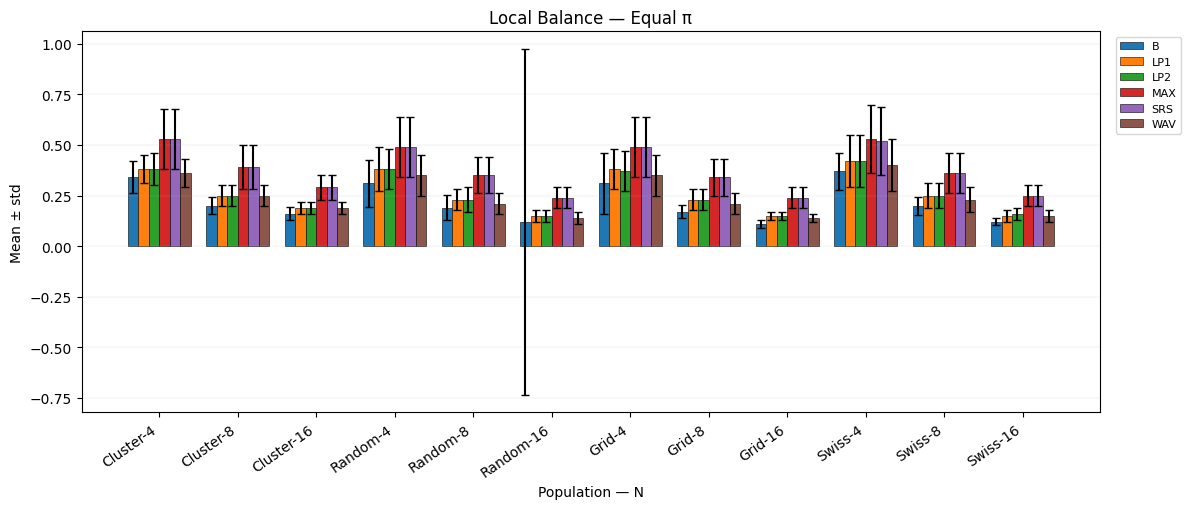

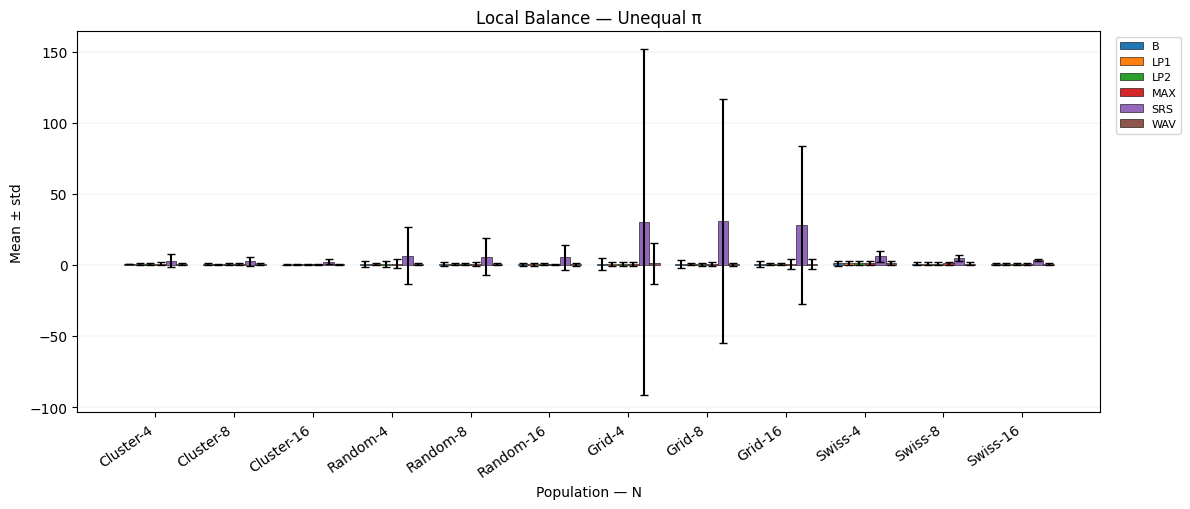

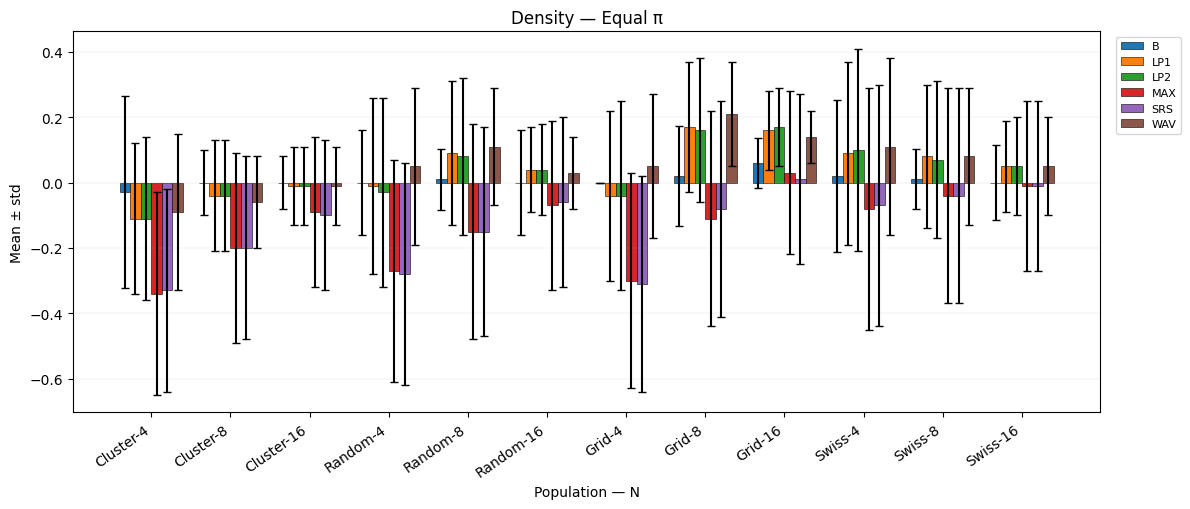

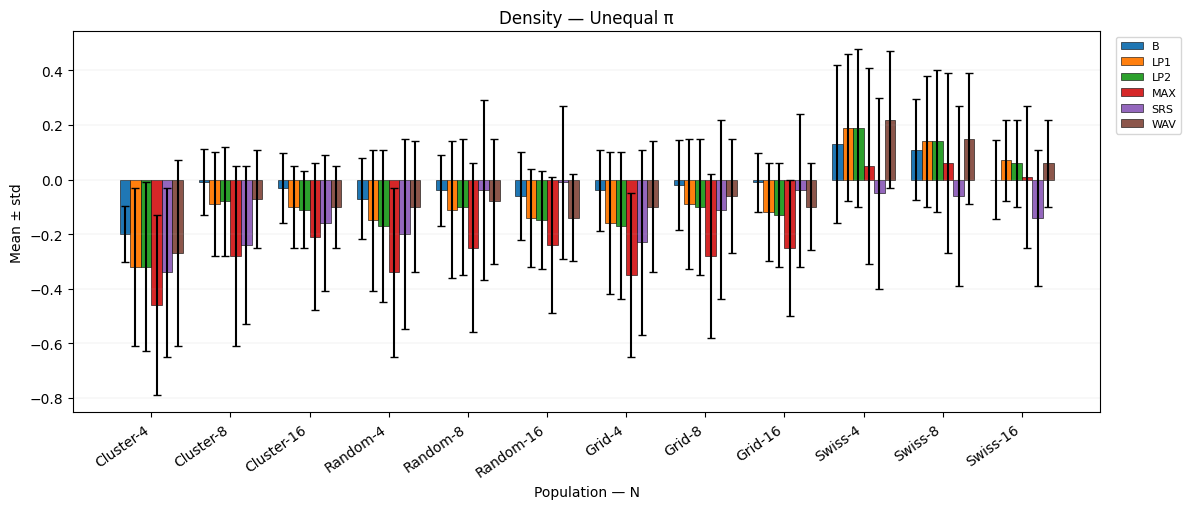

['/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final/bars_I_eq.png',
 '/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final/bars_I_uneq.png',
 '/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final/bars_L_eq.png',
 '/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final/bars_L_uneq.png',
 '/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final/bars_D_eq.png',
 '/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final/bars_D_uneq.png']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Config ----
csv_path = Path("/home/divar/projects/graphical-sampling/simulation_results/Final_Results_4_Popu_Final.csv")
out_dir = Path("/home/divar/projects/graphical-sampling/simulation_results/plots_bars_4_popu_final")
out_dir.mkdir(parents=True, exist_ok=True)

# Measures to plot (exclude Voronoi)
MEASURES = ["I", "L", "D"]
PI_ORDER = ["eq", "uneq"]
POPU_ORDER = ["clust", "random", "grid", "swiss"]
N_ORDER = [4, 8, 16]
POPU_LABELS = {"clust": "Cluster", "random": "Random", "grid": "Grid", "swiss": "Swiss"}
PI_LABELS = {"eq": "Equal π", "uneq": "Unequal π"}
MEASURE_LABELS = {"I": "Moran's I", "L": "Local Balance", "D": "Density"}

# ---- Load ----
df = pd.read_csv(csv_path)
# Basic cleanup
df["Popu"] = df["Popu"].astype(str).str.lower().replace({"cluster": "clust"})
df["pi"] = df["pi"].astype(str).str.lower().replace({"equal": "eq", "unequal": "uneq", "uequal": "uneq"})
df["N"] = pd.to_numeric(df["N"], errors="coerce").astype("Int64")
df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
df["std"] = pd.to_numeric(df["std"], errors="coerce")

# Keep only requested measures
df = df[df["Measure"].isin(MEASURES)].copy()

def plot_grouped_bars(measure, pi):
    sub = df[(df["Measure"] == measure) & (df["pi"] == pi)].copy()
    if sub.empty:
        return None
    
    # Include GRZ only for Moran's I
    if measure != "I":
        sub = sub[sub["Method"] != "GRZ"].copy()
    
    # Build categories along x-axis: one per (Popu, N)
    cats = []
    for pop in POPU_ORDER:
        for n in N_ORDER:
            if ((sub["Popu"] == pop) & (sub["N"] == n)).any():
                cats.append((pop, int(n)))
    if not cats:
        return None
    
    # Methods present in this subset (in a stable order: B, GRZ, then others alpha by name)
    methods_present = sub["Method"].dropna().astype(str).unique().tolist()
    # Put B first, GRZ second (if present), others sorted
    ordered = []
    for m in ["B", "GRZ"]:
        if m in methods_present:
            ordered.append(m)
    for m in sorted([m for m in methods_present if m not in ["B", "GRZ"]]):
        ordered.append(m)
    methods_present = ordered
    
    # Prepare positions
    base_x = np.arange(len(cats), dtype=float)
    mcount = max(1, len(methods_present))
    bar_w = min(0.8 / mcount, 0.15)
    
    # Create figure
    plt.figure(figsize=(12, 5.2))
    
    # For each method, collect aligned values over categories
    for i, m in enumerate(methods_present):
        xs = []
        ys = []
        es = []
        for idx, (pop, n) in enumerate(cats):
            row = sub[(sub["Popu"] == pop) & (sub["N"] == n) & (sub["Method"].astype(str) == m)]
            if not row.empty:
                xs.append(base_x[idx] + (i - (mcount - 1) / 2.0) * bar_w)
                ys.append(float(row["mean"].iloc[0]))
                es.append(float(row["std"].iloc[0]))
            else:
                # skip missing bars for this method/category
                pass
        
        if xs:
            plt.bar(xs, ys, yerr=es, width=bar_w, capsize=3, edgecolor="black", linewidth=0.4, label=m)
    
    # X ticks & labels
    xticks = base_x
    xticklabels = [f"{POPU_LABELS.get(p,p).split()[0]}-{n}" for (p, n) in cats]  # e.g., Cluster-4
    plt.xticks(xticks, xticklabels, rotation=35, ha="right")
    
    # Titles & labels
    plt.title(f"{MEASURE_LABELS.get(measure, measure)} — {PI_LABELS.get(pi, pi)}")
    plt.xlabel("Population — N")
    plt.ylabel("Mean ± std")
    plt.grid(axis="y", linewidth=0.3, alpha=0.4)
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
    plt.tight_layout()
    
    # Save and also show
    fname = f"bars_{measure}_{pi}.png"
    out_path = out_dir / fname
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    return out_path

# Generate the six figures
paths = []
for measure in MEASURES:
    for pi in PI_ORDER:
        p = plot_grouped_bars(measure, pi)
        if p:
            paths.append(str(p))

# Finally, display all figures now
plt.show()

paths


In [18]:
# paper_bars_6figs.py
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV = "combined_results_v3.csv"
OUTDIR = Path("paper_plots")
OUTDIR.mkdir(exist_ok=True)

MEASURES = ["I","L","D"]                 # ignore Voronoi
MEASURE_NAMES = {"I":"Moran’s I", "L":"Local Balance", "D":"Density"}
POPUS = ["clust","random","grid","swiss"]
POPU_NAMES = {"clust":"Cluster","random":"Random","grid":"Grid","swiss":"Swiss"}
PIS = ["eq","uneq"]
PI_NAMES = {"eq":"Equal π","uneq":"Unequal π"}
NS = [4,8,16]

# Put the ones you care about first; others will follow after
METHOD_ORDER = ["B","GRZ","MAX","LP1","LP2","WAV","SRS","HIP","DAS","GRT","SPI"]
INCLUDE_METHODS = None  # e.g. ["B","GRZ","MAX","LP1","LP2"]; set None to include all present

def load_df(path):
    df = pd.read_csv(path)
    df = df[df["Measure"].isin(MEASURES)].copy()
    df["Popu"] = df["Popu"].str.lower()
    df["N"] = df["N"].astype(int)
    df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
    df["std"]  = pd.to_numeric(df["std"], errors="coerce")
    df = df.dropna(subset=["mean","std"])
    if INCLUDE_METHODS:
        df = df[df["Method"].isin(INCLUDE_METHODS)]
    # order methods deterministically
    methods_present = df["Method"].dropna().unique().tolist()
    methods_sorted = [m for m in METHOD_ORDER if m in methods_present] + \
                     [m for m in methods_present if m not in METHOD_ORDER]
    df["Method"] = pd.Categorical(df["Method"], categories=methods_sorted, ordered=True)
    return df, methods_sorted

def method_pal(methods):
    # consistent color/marker per method across figures
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    while len(colors) < len(methods):
        colors += colors
    cmap = {m: colors[i] for i,m in enumerate(methods)}
    return cmap

def global_ylim(df_sub):
    lo = (df_sub["mean"] - df_sub["std"]).min()
    hi = (df_sub["mean"] + df_sub["std"]).max()
    if not np.isfinite(lo) or not np.isfinite(hi):
        return None
    pad = 0.06 * (hi - lo if hi > lo else 1.0)
    return (lo - pad, hi + pad)

def plot_one_figure(df, methods, measure, pi):
    dfx = df[(df["Measure"]==measure) & (df["pi"]==pi)]
    if dfx.empty:
        return
    cmap = method_pal(methods)
    ylim = global_ylim(dfx)

    fig, axs = plt.subplots(
        nrows=len(NS), ncols=len(POPUS),
        figsize=(11.2, 7.0), sharex=False, sharey=True, constrained_layout=True
    )

    # shared legend handles
    handles = []
    for r, N in enumerate(NS):
        for c, pop in enumerate(POPUS):
            ax = axs[r, c]
            sub = dfx[(dfx["N"]==N) & (dfx["Popu"]==pop)]
            ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
            ax.grid(axis="y", linewidth=0.3, alpha=0.4)

            if sub.empty:
                ax.set_title(f"{POPU_NAMES[pop]}, N={N}")
                ax.set_xticks([])
                continue

            # bar chart: one bar per method
            sub = sub.sort_values("Method")
            x = np.arange(len(sub))
            vals = sub["mean"].to_numpy()
            errs = sub["std"].to_numpy()
            cols = [cmap[m] for m in sub["Method"].astype(str).tolist()]

            bars = ax.bar(x, vals, yerr=errs, capsize=3, edgecolor="black",
                          linewidth=0.4, color=cols)
            ax.set_title(f"{POPU_NAMES[pop]}, N={N}")
            ax.set_xticks(x)
            ax.set_xticklabels(sub["Method"].astype(str), rotation=45, ha="right")

            if r == 0 and c == 0:
                # make legend once
                for m in sub["Method"].astype(str):
                    handles.append(plt.Line2D([0],[0], color=cmap[m], lw=6, label=m))

            if ylim:
                ax.set_ylim(*ylim)

    # figure title and legend
    fig.suptitle(f"{MEASURE_NAMES[measure]} — {PI_NAMES[pi]}", fontsize=12)
    if handles:
        # unique by label while preserving order
        seen, uniq = set(), []
        for h in handles:
            if h.get_label() not in seen:
                uniq.append(h); seen.add(h.get_label())
        fig.legend(uniq, [h.get_label() for h in uniq],
                   loc="upper center", ncol=min(8, len(uniq)), frameon=False)

    out = OUTDIR / f"{measure}_{pi}_bars.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("saved:", out)

def main():
    df, methods_sorted = load_df(CSV)
    for measure in MEASURES:
        for pi in PIS:
            plot_one_figure(df, methods_sorted, measure, pi)

if __name__ == "__main__":
    main()


saved: paper_plots/I_eq_bars.png
saved: paper_plots/I_uneq_bars.png
saved: paper_plots/L_eq_bars.png
saved: paper_plots/L_uneq_bars.png
saved: paper_plots/D_eq_bars.png
saved: paper_plots/D_uneq_bars.png


In [17]:

# paper_plots.py
# Multi-panel, publication-ready figures (≤ 3 pages) from combined_results_v3.csv
# - One page per measure (I, L, D), 2×4 subplots: rows = {Equal π, Unequal π}, cols = {Cluster, Random, Grid, Swiss}
# - Lines = methods; shaded area = ± std
# - Shared legend per page, consistent colors/markers across pages
# Run: python paper_plots.py

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

CSV = "combined_results_v3.csv"    # put next to this script
OUT_PDF = "results_plots.pdf"      # 3 pages (I, L, D)
SAVE_PNG_TOO = False               # set True to also save PNG per page

# Include only these measures for the paper (user asked to ignore Voronoi)
MEASURES = ["I","L","D"]
POPU_ORDER = ["clust","random","grid","swiss"]
PI_ORDER = ["eq","uneq"]
POPU_LABELS = {"clust":"Cluster","random":"Random","grid":"Grid","swiss":"Swiss"}
PI_LABELS   = {"eq":"Equal π","uneq":"Unequal π"}
MEASURE_LABELS = {"I":"Moran’s I","L":"Local Balance","D":"Density"}

# Order methods in legend; any others will follow after
METHOD_ORDER = ["B","GRZ","MAX","LP1","LP2","WAV","SRS","HIP","DAS","GRT","SPI"]

# Optional: restrict the plotted methods to reduce clutter (set to None to include all)
INCLUDE_METHODS = None  # e.g., ["B","GRZ","MAX","LP1","LP2","WAV","SRS"]

# Style tuning for paper
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "grid.linewidth": 0.3,
})

def load_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["N"] = pd.to_numeric(df["N"], errors="coerce").astype("Int64")
    df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
    df["std"]  = pd.to_numeric(df["std"], errors="coerce")
    df["Popu"] = df["Popu"].str.lower()
    df = df.dropna(subset=["N","mean","std","Popu","pi","Method","Measure"]).copy()

    # keep only requested measures
    df = df[df["Measure"].isin(MEASURES)].copy()

    # method filter if set
    if INCLUDE_METHODS:
        df = df[df["Method"].isin(INCLUDE_METHODS)].copy()

    # consistent method ordering
    cats = METHOD_ORDER + [m for m in df["Method"].unique() if m not in METHOD_ORDER]
    df["Method"] = pd.Categorical(df["Method"], categories=cats, ordered=True)

    # constrain orders
    df["Popu"] = pd.Categorical(df["Popu"], categories=POPU_ORDER, ordered=True)
    df["pi"]   = pd.Categorical(df["pi"], categories=PI_ORDER, ordered=True)

    return df

def method_style(methods):
    # Consistent colors/markers for methods across pages
    base_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
                                                                         "#9467bd","#8c564b","#e377c2","#7f7f7f",
                                                                         "#bcbd22","#17becf"])
    # repeat if needed
    while len(base_colors) < len(methods):
        base_colors += base_colors
    # markers cycle
    base_markers = ["o","s","^","D","v","P","X","*","h","+","x",">","<"]
    while len(base_markers) < len(methods):
        base_markers += base_markers

    color_map, marker_map, width_map, dash_map = {}, {}, {}, {}
    for i, m in enumerate(methods):
        color_map[m] = base_colors[i]
        marker_map[m] = base_markers[i]
        # Emphasize B (reference) and GRZ (new)
        if m == "B":
            width_map[m] = 1.8
            dash_map[m]  = (3,2)
        elif m == "GRZ":
            width_map[m] = 2.2
            dash_map[m]  = None
        else:
            width_map[m] = 1.4
            dash_map[m]  = None
    return color_map, marker_map, width_map, dash_map

def compute_ylim(df_meas):
    # global y-limits per measure (across all subplots) with a small margin
    y_min = (df_meas["mean"] - df_meas["std"]).min()
    y_max = (df_meas["mean"] + df_meas["std"]).max()
    if not np.isfinite(y_min) or not np.isfinite(y_max):
        return None
    pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.1
    return (y_min - pad, y_max + pad)

def plot_page_for_measure(df, measure, pdf: PdfPages):
    dfm = df[df["Measure"]==measure].copy()
    if dfm.empty:
        return

    methods_present = [m for m in dfm["Method"].cat.categories if m in dfm["Method"].unique()]
    color_map, marker_map, width_map, dash_map = method_style(methods_present)
    ylim = compute_ylim(dfm)

    fig, axs = plt.subplots(2, 4, figsize=(11.69, 8.27), sharex=True, sharey=True, constrained_layout=True)  # A4 landscape
    handles, labels = [], []

    for r, pi in enumerate(PI_ORDER):
        for c, popu in enumerate(POPU_ORDER):
            ax = axs[r, c]
            sub = dfm[(dfm["pi"]==pi) & (dfm["Popu"]==popu)].copy()
            if sub.empty:
                ax.set_visible(False)
                continue

            # plot each method: line + band
            for m in methods_present:
                g = sub[sub["Method"]==m].sort_values("N")
                if g.empty: 
                    continue
                x = g["N"].astype(int).values
                y = g["mean"].values
                s = g["std"].values
                (ln,) = ax.plot(x, y, marker=marker_map[m], linewidth=width_map[m],
                                label=m, color=color_map[m], linestyle="-" if dash_map[m] is None else (0, dash_map[m]))
                ax.fill_between(x, y - s, y + s, alpha=0.15, linewidth=0, color=color_map[m])

            # grid & titles
            ax.grid(True, alpha=0.4, linewidth=0.3)
            if r == 0:
                ax.set_title(POPU_LABELS.get(popu, popu))
            if c == 0:
                ax.set_ylabel(PI_LABELS.get(pi, pi))
            ax.set_xticks(sorted(sub["N"].astype(int).unique()))
            # Collect legend handles once
            if r == 0 and c == 0:
                for m in methods_present:
                    h = plt.Line2D([0],[0], color=color_map[m], marker=marker_map[m],
                                   linestyle="-" if dash_map[m] is None else (0, dash_map[m]),
                                   linewidth=width_map[m], label=m)
                    handles.append(h); labels.append(m)

    # global labels
    fig.suptitle(MEASURE_LABELS.get(measure, measure), y=1.02, fontsize=11)
    fig.supxlabel("Sample size (N)")
    fig.supylabel("Mean ± std")

    # shared legend at bottom
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 8), frameon=False, bbox_to_anchor=(0.5, -0.02))

    # consistent y-limits
    if ylim:
        for ax in fig.get_axes():
            if hasattr(ax, "set_ylim"):
                ax.set_ylim(ylim)

    pdf.savefig(fig, bbox_inches="tight")
    if SAVE_PNG_TOO:
        Path("plots_pages").mkdir(exist_ok=True)
        fig.savefig(Path("plots_pages") / f"page_{measure}.png", dpi=300, bbox_inches="tight")
        
    import matplotlib.pyplot as plt
    plt.show()
    plt.close(fig)

def main():
    df = load_data(CSV)
    with PdfPages(OUT_PDF) as pdf:
        for measure in MEASURES:
            plot_page_for_measure(df, measure, pdf)
    print(f"Wrote {OUT_PDF} (up to {len(MEASURES)} pages).")

if __name__ == "__main__":
    main()



UnboundLocalError: cannot access local variable 'plt' where it is not associated with a value

In [14]:
plt.show()


In [ ]:
# read_and_plot.py
# Reads combined_results_v3.csv and saves per-case plots (mean ± std vs N).
# Run: python read_and_plot.py

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

CSV = "combined_results_v3.csv"   # put the file next to this script
OUT = Path("plots")               # output folder for PNGs
OUT.mkdir(parents=True, exist_ok=True)

# Nicely ordered labels (others will follow at the end)
METHOD_ORDER = ["MAX","LP1","LP2","SRS","WAV","HIP","DAS","GRT","SPI","B","GRZ"]
POPU_LABELS = {"clust":"Cluster", "random":"Random", "grid":"Grid", "swiss":"Swiss"}
PI_LABELS   = {"eq":"Equal π", "uneq":"Unequal π"}
MEASURE_LABELS = {"I":"Moran's I", "L":"Local Balance", "D":"Density", "V":"Voronoi"}

# --- load & prep
df = pd.read_csv(CSV)
df["N"]    = df["N"].astype(int)
df["mean"] = pd.to_numeric(df["mean"], errors="coerce")
df["std"]  = pd.to_numeric(df["std"], errors="coerce")
df["Popu"] = df["Popu"].str.lower()

cats = METHOD_ORDER + [m for m in df["Method"].dropna().unique() if m not in METHOD_ORDER]
df["Method"] = pd.Categorical(df["Method"], categories=cats, ordered=True)

def plot_case(measure, popu, pi):
    sub = df[(df["Measure"]==measure) & (df["Popu"]==popu) & (df["pi"]==pi)].copy()
    if sub.empty:
        return
    methods = [m for m in sub["Method"].cat.categories if m in sub["Method"].unique()]
    plt.figure()
    for m in methods:
        g = sub[sub["Method"]==m].sort_values("N")
        if g.empty: 
            continue
        plt.errorbar(g["N"].values, g["mean"].values, yerr=g["std"].values, marker="o", linestyle="-", label=str(m))
    title = f"{MEASURE_LABELS.get(measure, measure)} — {POPU_LABELS.get(popu, popu)} ({PI_LABELS.get(pi, pi)})"
    plt.title(title)
    plt.xlabel("Sample size (N)")
    plt.ylabel("Mean ± std")
    plt.grid(True, linewidth=0.4, alpha=0.6)
    if len(methods) > 6:
        plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
        plt.tight_layout(rect=[0,0,0.8,1])
    else:
        plt.legend(loc="best", fontsize=8)
        plt.tight_layout()
    safe = title.replace(" ", "_").replace("±","").replace("—","-").replace("'","")
    plt.savefig(OUT / f"{safe}.png", bbox_inches="tight", dpi=150)
    plt.close()

# per-case plots
for measure in ["I","L","D","V"]:
    for popu in ["clust","random","grid","swiss"]:
        for pi in ["eq","uneq"]:
            plot_case(measure, popu, pi)

# quick overall-by-method per measure (averaged across populations & π)
def plot_overall(measure):
    sub = df[df["Measure"]==measure]
    if sub.empty: 
        return
    agg = sub.groupby(["Method","N"], as_index=False).agg(mean=("mean","mean"), std=("std","mean"))
    plt.figure()
    for m, g in agg.groupby("Method"):
        g = g.sort_values("N")
        plt.errorbar(g["N"].values, g["mean"].values, yerr=g["std"].values, marker="o", linestyle="-", label=str(m))
    plt.title(f"Overall (averaged) — {MEASURE_LABELS.get(measure, measure)}")
    plt.xlabel("Sample size (N)")
    plt.ylabel("Mean ± avg std")
    plt.grid(True, linewidth=0.4, alpha=0.6)
    if agg["Method"].nunique() > 6:
        plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
        plt.tight_layout(rect=[0,0,0.8,1])
    else:
        plt.legend(loc="best", fontsize=8)
        plt.tight_layout()
    name = f"Overall_{MEASURE_LABELS.get(measure, measure).replace(' ','_')}.png"
    plt.savefig(OUT / name, bbox_inches="tight", dpi=150)
    plt.close()

for m in ["I","L","D","V"]:
    plot_overall(m)


usage: ipykernel_launcher.py [-h] [--csv CSV] [--out OUT]
                             [--include [INCLUDE ...]]
                             [--exclude [EXCLUDE ...]]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1000/jupyter/runtime/kernel-v36817b0f84025b108493cbf37531edb177a79bce9.json


SystemExit: 2

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3678: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


/tmp/ipykernel_579992/499598239.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


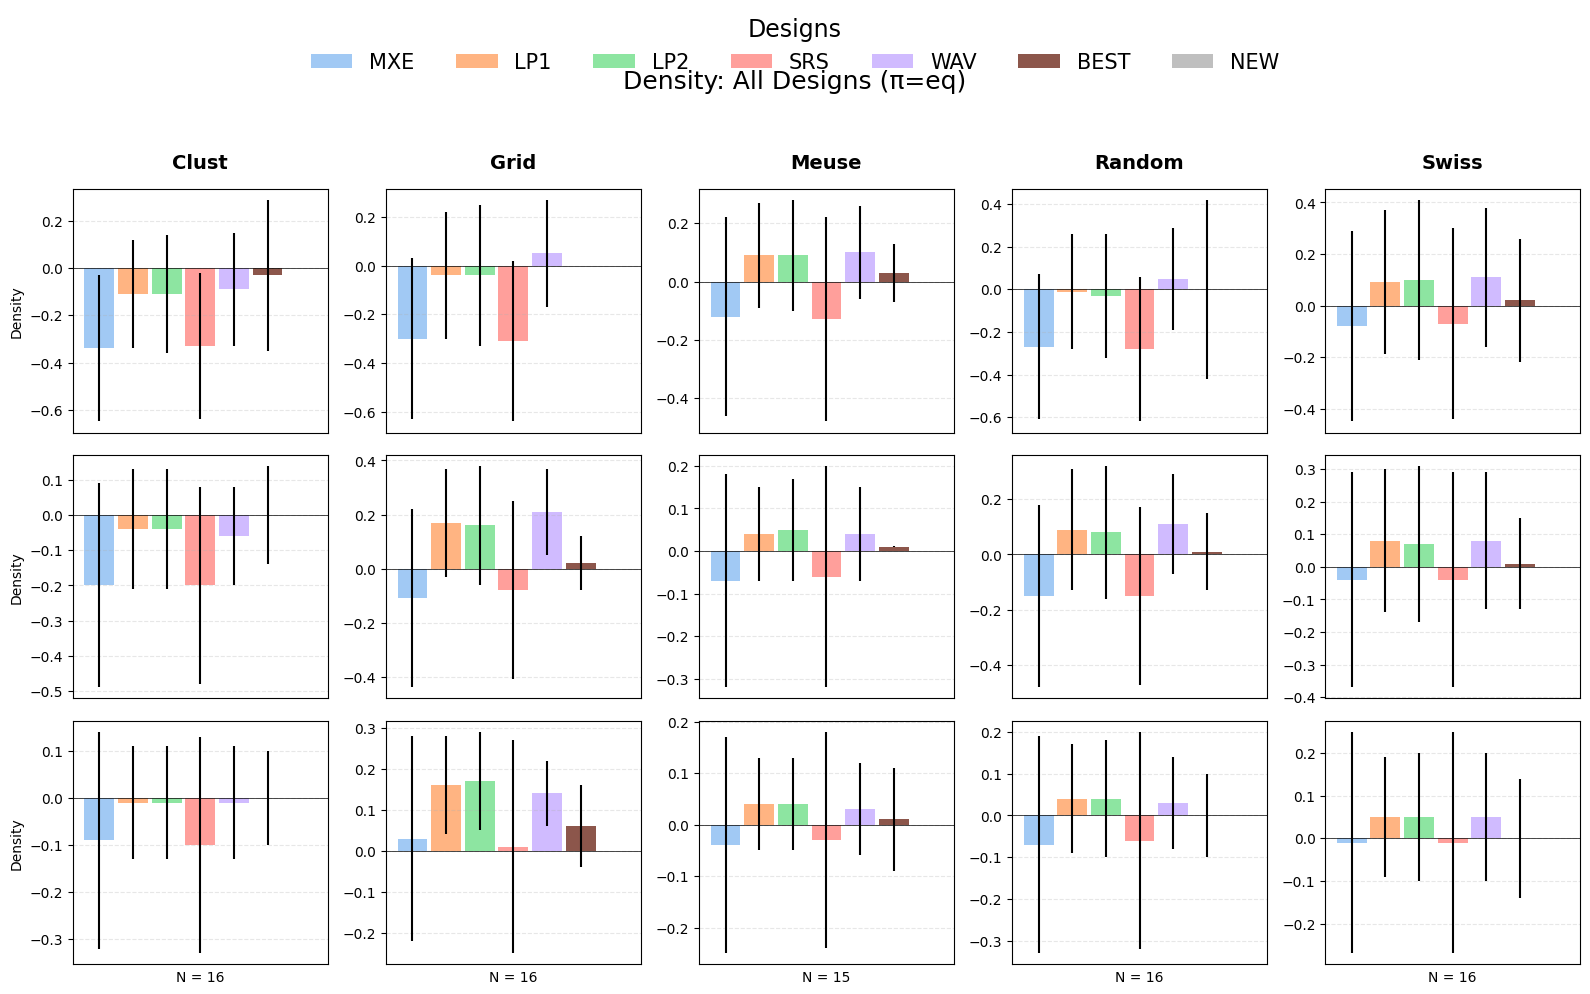

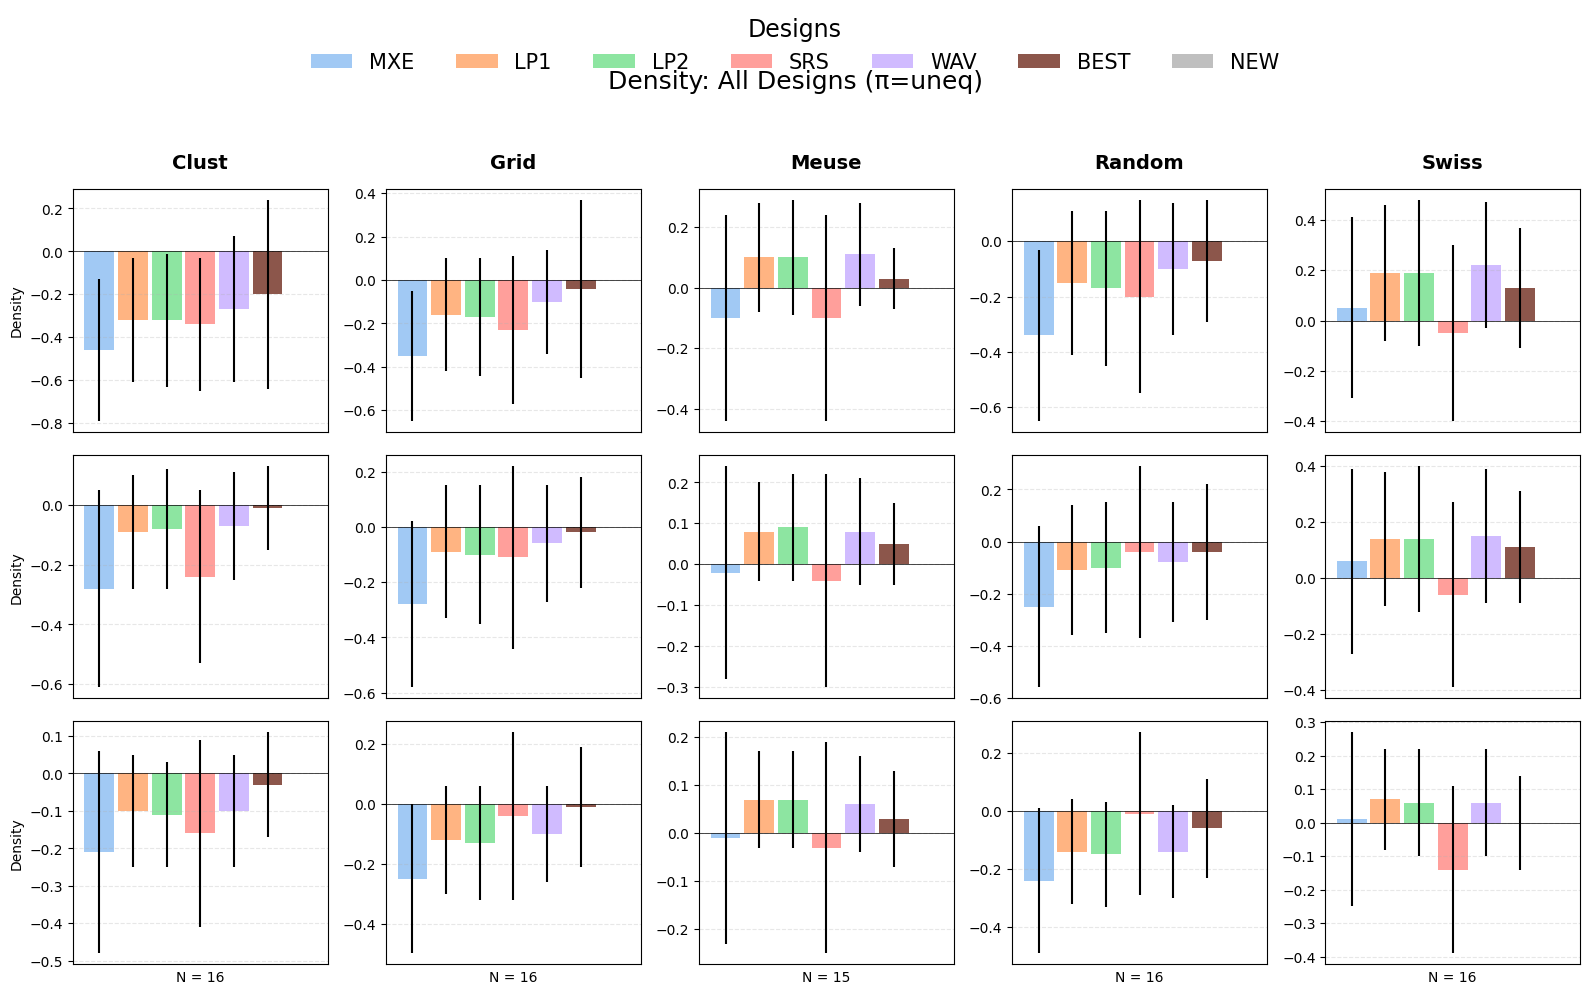

/tmp/ipykernel_579992/499598239.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


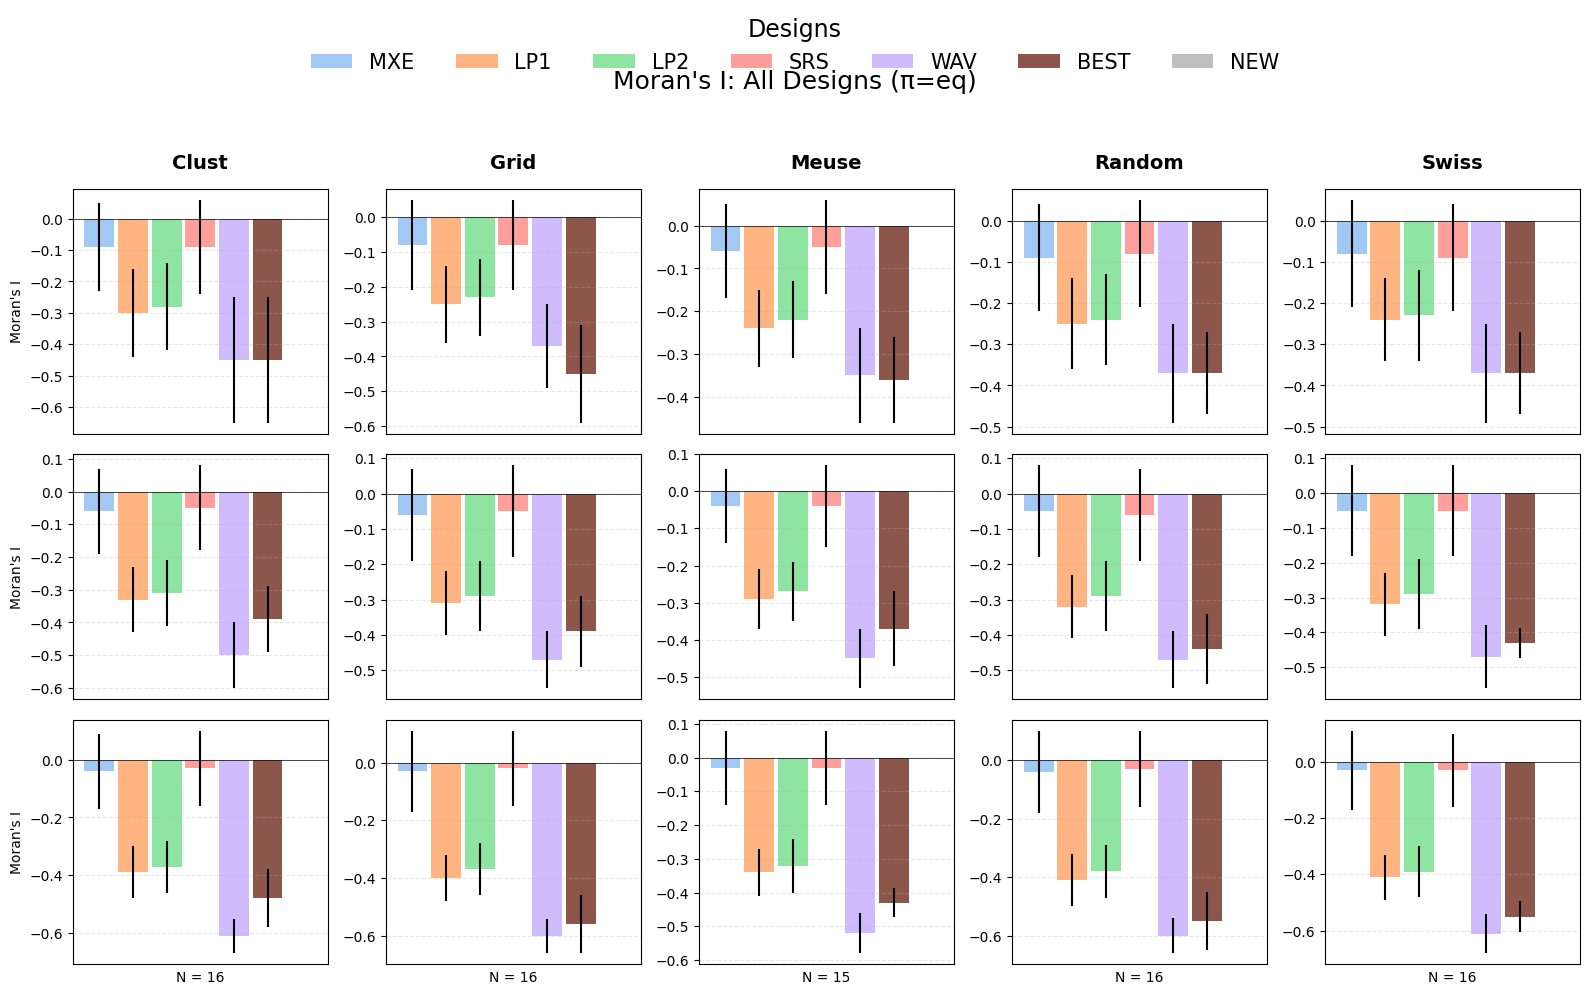

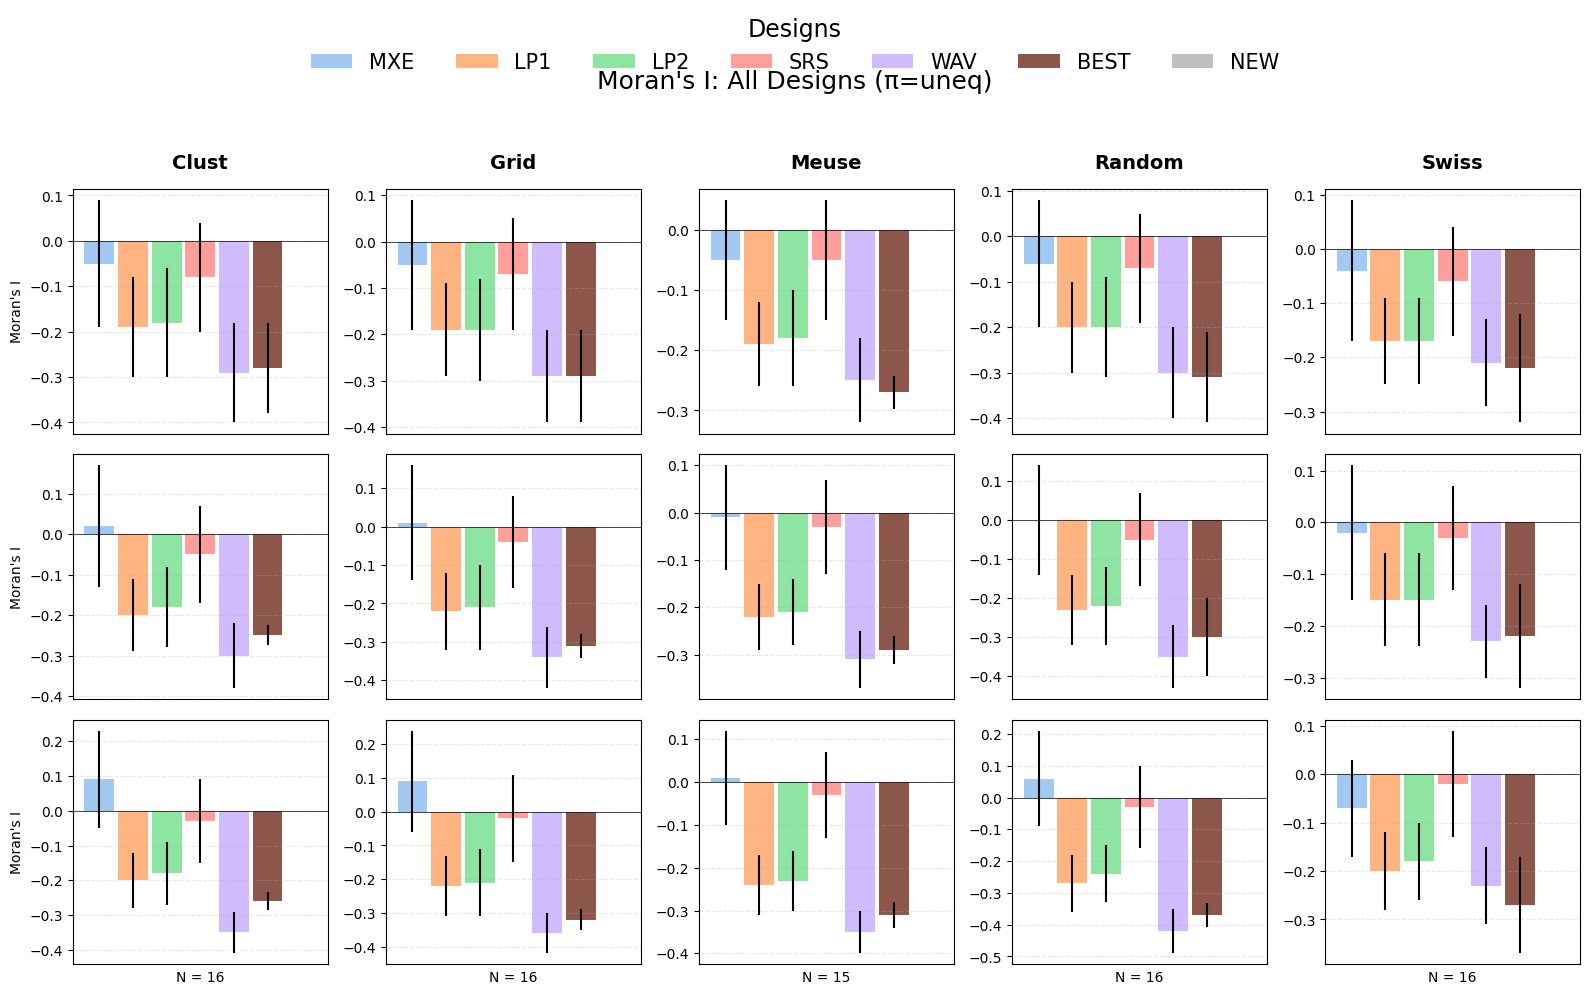

/tmp/ipykernel_579992/499598239.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


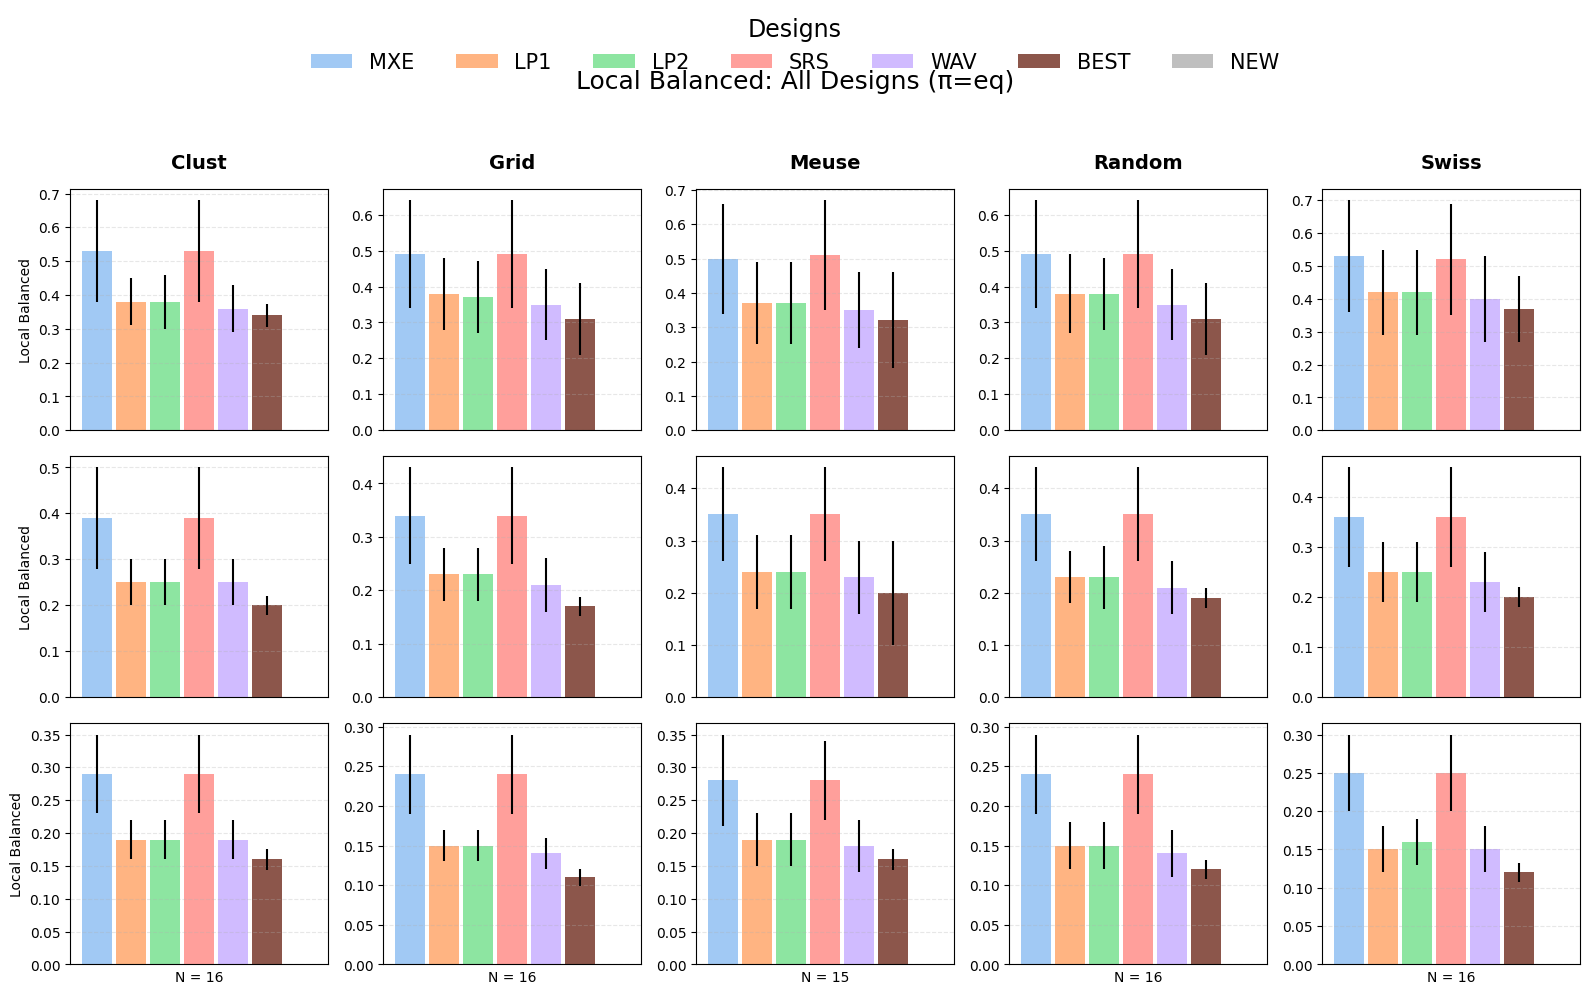

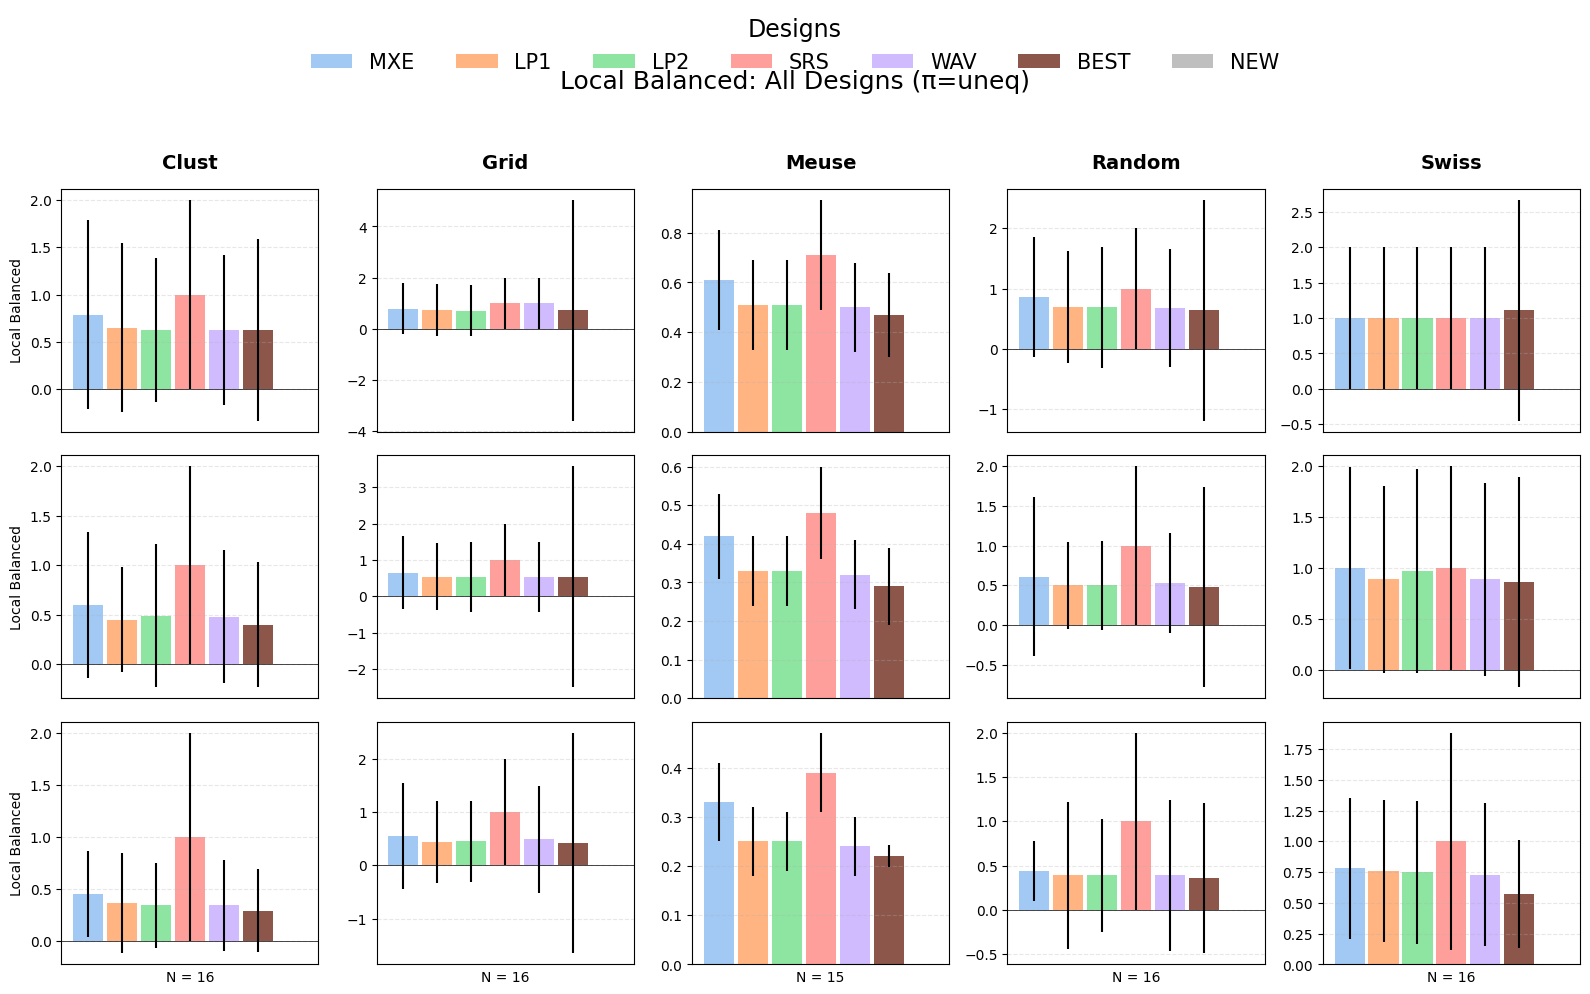

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_latex_table(path):
    """Parse a pandas-generated LaTeX table into a DataFrame."""
    with open(path, 'r') as f:
        lines = f.readlines()
    # Find header
    header_idx = next(i for i, line in enumerate(lines) if r"\toprule" in line) + 1
    cols = [c.strip() for c in lines[header_idx].strip().rstrip(r"\\").split('&')]
    data = []
    for line in lines[header_idx+2:]:
        if r"\bottomrule" in line:
            break
        parts = [p.strip() for p in line.strip().rstrip(r"\\").split('&')]
        if len(parts) == len(cols):
            data.append(parts)
    df = pd.DataFrame(data, columns=cols)
    return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Paths to the accurate tables

table_paths = {
    'D': '/home/divar/projects/graphical-sampling/simulation_results/density_comparison_accurate.tex',
    'I': '/home/divar/projects/graphical-sampling/simulation_results/moran_comparison_accurate.tex',
    'L': '/home/divar/projects/graphical-sampling/simulation_results/local_balanced_comparison_accurate.tex'
}
labels = {'D': 'Density', 'I': "Moran's I", 'L': 'Local Balanced'}

# Abbrev map for designs
abbr = {'UPmaxentropy':'MXE','lpm1':'LP1','lpm2':'LP2','srs':'SRS','wave':'WAV'}

# Colors
colors = sns.color_palette("pastel", n_colors=len(abbr))
new_color = 'gray'
best_color = 'C5'

# Setup
populations = ['clust','grid','meuse','random','swiss']
sample_map = {
    'clust':  [4,8,16],
    'grid':   [4,8,16],
    'meuse':  [5,10,15],
    'random': [4,8,16],
    'swiss':  [4,8,16]
}
designs = ['UPmaxentropy','lpm1','lpm2','srs','wave']

# Generate plots
for crit, path in table_paths.items():
    df = parse_latex_table(path)
    # rename and convert
    df = df.rename(columns={'Popu':'Popu',r'$\pi$':'pi','N':'N','Desings':'Design',
                            f'{crit}_m':'mu',f'{crit}_{{std}}':'sd',
                            f'B {crit}_m':'bmu',f'B {crit}_{{std}}':'bsd'})
    df['mu'] = df['mu'].astype(float)
    df['sd'] = df['sd'].astype(float)
    df['bmu'] = df['bmu'].astype(float)
    df['bsd'] = df['bsd'].astype(float)
    df['pi'] = df['pi'].str.strip()
    df['Popu'] = df['Popu'].str.strip()
    df['N'] = df['N'].astype(int)

    for pi in ['eq','uneq']:
        fig, axs = plt.subplots(3,5,figsize=(16,10),sharey=False)
        fig.suptitle(f"{labels[crit]}: All Designs (π={pi})", fontsize=18, y=0.93)
        # column headers
        for col, pop in enumerate(populations):
            axs[0,col].set_title(pop.capitalize(), pad=15, fontsize=14, fontweight='bold')

        # subplots
        for col, pop in enumerate(populations):
            for row, N in enumerate(sample_map[pop]):
                ax = axs[row,col]
                sub = df[(df['Popu']==pop)&(df['pi']==pi)&(df['N']==N)]
                x = np.arange(len(designs)+2)
                width = 6.2/(len(designs)+2)
                # rivals
                for i,d in enumerate(designs):
                    r = sub[sub['Design']==d]
                    mu = min(1,r['mu'].iloc[0]) if not r.empty else 0.0
                    sd = min(1, r['sd'].iloc[0]) if not r.empty else 0.0
                    ax.bar(x[i], mu, width, yerr=sd, color=colors[i], label=abbr[d] if row==0 and col==0 else "")
                # best
                if not sub.empty:
                    bmu = sub['bmu'].iloc[0]
                    if sub['bsd'].iloc[0]>0:
                        bsd = sub['bsd'].iloc[0]
                    else:
                        bsd = min(.06, abs(bmu) * .1)  # default error if not provided
                else:
                    bmu = bsd = 0.0
                ax.bar(x[len(designs)], bmu, width, yerr=bsd, color=best_color, label='BEST' if row==0 and col==0 else "")
                # new
                ax.bar(x[-1], 0, width, color=new_color, alpha=0.5, label='NEW' if row==0 and col==0 else "")
                ax.axhline(0,color='black',lw=0.5)
                ax.set_xticks([])
                if col==0: ax.set_ylabel(labels[crit])
                if row==2: ax.set_xlabel(f"N = {N}")
                ax.grid(True,ls='--',alpha=0.3)

        # legend
        handles, labels_ = axs[0,0].get_legend_handles_labels()
        fig.legend(handles, labels_, title='Designs',
                   loc='upper center',bbox_to_anchor=(0.5,1.00),
                   ncol=len(handles),frameon=False,fontsize=15,title_fontsize=17)
        plt.tight_layout(rect=[0,0,1,0.90])
        plt.show()


In [1]:
import pandas as pd
import os

RESULTS_DIR = "/home/divar/projects/graphical-sampling/data_samples/results"

# 1) load your old summary
old = pd.read_csv(os.path.join(RESULTS_DIR, "summary_stats.csv"))

# 2) load your new KMS evaluation
new = pd.read_csv(os.path.join(RESULTS_DIR, "evaluate_all.csv"))

# 3) aggregate KMS over its config‐combos
agg = {
    'exp_density':'mean','median_density':'mean','var_density':'mean','min_density':'mean','max_density':'mean',
    'exp_IB':'mean','median_IB':'mean','var_IB':'mean','min_IB':'mean','max_IB':'mean',
    'exp_LB':'mean','median_LB':'mean','var_LB':'mean','min_LB':'mean','max_LB':'mean',
}
new_summary = (
    new
    .groupby(['coord','prob','n'], as_index=False)
    .agg(agg)
)

# 4) label and rename columns to match old
new_summary['method'] = 'KMS'
new_summary = new_summary.rename(columns={
    'coord':'population',
    'prob':'ptype',
    'exp_density':'D_mu',
    'median_density':'D_me',
    'var_density':'D_sd',
    'min_density':'D_mn',
    'max_density':'D_mx',
    'exp_IB':'I_mu',
    'median_IB':'I_me',
    'var_IB':'I_sd',
    'min_IB':'I_mn',
    'max_IB':'I_mx',
    'exp_LB':'L_mu',
    'median_LB':'L_me',
    'var_LB':'L_sd',
    'min_LB':'L_mn',
    'max_LB':'L_mx',
})

new_summary = new_summary[
    ['population','ptype','n','method',
     'D_mu','D_me','D_sd','D_mn','D_mx',
     'I_mu','I_me','I_sd','I_mn','I_mx',
     'L_mu','L_me','L_sd','L_mn','L_mx']
]

# 5) concat old + new
combined = pd.concat([old, new_summary], ignore_index=True)

# 6) split “population” on underscore into population + ptype,
#    and map eq→EQ, uneq→UQ
mask = combined['population'].str.contains('_')
parts = combined.loc[mask, 'population'].str.rsplit('_', n=1, expand=True)
combined.loc[mask, 'population'] = parts[0]
combined.loc[mask, 'ptype']      = parts[1].map({'eq':'EQ', 'uneq':'UQ'})
combined[ 'ptype']      = combined[ 'ptype'].map({'eq':'EQ', 'uneq':'UQ'})

# 7) enforce method ordering and sort
method_order = ["SRS","UPM","LP1","LP2","WAV","KMS"]
combined['method'] = pd.Categorical(combined['method'],
                                    categories=method_order,
                                    ordered=True)

combined = combined.sort_values(
    by=['population','ptype','n','method'],
    ignore_index=True
)

# 8) write out and inspect
out_path = os.path.join(RESULTS_DIR, "summary_all_methods.csv")
combined.to_csv(out_path, index=False, float_format="%.2f")
print("✔ Wrote:", out_path)
print(combined.to_string())


FileNotFoundError: [Errno 2] No such file or directory: '/home/divar/projects/graphical-sampling/data_samples/results/summary_stats.csv'

In [ ]:
import pandas as pd
import os

RESULTS_DIR = "/home/divar/projects/graphical-sampling/data_samples/results"

# 1) load your old summary
old = pd.read_csv(os.path.join(RESULTS_DIR, "summary_stats.csv"))

# 3) aggregate KMS over its config‐combos
agg = {
    'exp_density':'mean','median_density':'mean','var_density':'mean','min_density':'mean','max_density':'mean',
    'exp_IB':'mean','median_IB':'mean','var_IB':'mean','min_IB':'mean','max_IB':'mean',
    'exp_LB':'mean','median_LB':'mean','var_LB':'mean','min_LB':'mean','max_LB':'mean',
}
new_summary = (
    new
    .groupby(['coord','prob','n'], as_index=False)
    .agg(agg)
)

# 4) label and rename columns to match old
new_summary['method'] = 'KMS'
new_summary = new_summary.rename(columns={
    'coord':'population',
    'prob':'ptype',
    'exp_density':'D_mu',
    'median_density':'D_me',
    'var_density':'D_sd',
    'min_density':'D_mn',
    'max_density':'D_mx',
    'exp_IB':'I_mu',
    'median_IB':'I_me',
    'var_IB':'I_sd',
    'min_IB':'I_mn',
    'max_IB':'I_mx',
    'exp_LB':'L_mu',
    'median_LB':'L_me',
    'var_LB':'L_sd',
    'min_LB':'L_mn',
    'max_LB':'L_mx',
})

new_summary = new_summary[
    ['population','ptype','n','method',
     'D_mu','D_me','D_sd','D_mn','D_mx',
     'I_mu','I_me','I_sd','I_mn','I_mx',
     'L_mu','L_me','L_sd','L_mn','L_mx']
]

# 5) concat old + new
combined = pd.concat([old, new_summary], ignore_index=True)

# 6) split “population” on underscore into population + ptype,
#    and map eq→EQ, uneq→UQ
mask = combined['population'].str.contains('_')
parts = combined.loc[mask, 'population'].str.rsplit('_', n=1, expand=True)
combined.loc[mask, 'population'] = parts[0]
combined.loc[mask, 'ptype']      = parts[1].map({'eq':'EQ', 'uneq':'UQ'})
combined[ 'ptype']      = combined[ 'ptype'].map({'eq':'EQ', 'uneq':'UQ'})

# 7) enforce method ordering and sort
method_order = ["SRS","UPM","LP1","LP2","WAV","KMS"]
combined['method'] = pd.Categorical(combined['method'],
                                    categories=method_order,
                                    ordered=True)

combined = combined.sort_values(
    by=['population','ptype','n','method'],
    ignore_index=True
)

# 8) write out and inspect
out_path = os.path.join(RESULTS_DIR, "summary_all_methods.csv")
combined.to_csv(out_path, index=False, float_format="%.2f")
print("✔ Wrote:", out_path)
print(combined.to_string())


In [40]:
RESULTS_DIR = "/home/divar/projects/graphical-sampling/data_samples/results"


old = pd.read_csv(os.path.join(RESULTS_DIR, "summary_stats_new.csv"))
mask_old = old['method'] == 'wave'
sp_ind = 'D'
result = old.loc[mask_old,['population','method', 'ptype','n', f'{sp_ind}_mu', f'{sp_ind}_me', f'{sp_ind}_sd', f'{sp_ind}_mn', f'{sp_ind}_mx']]
display(result)

,population,method,ptype,n,D_mu,D_me,D_sd,D_mn,D_mx
4,clust,wave,eq,4,-0.09,-0.06,0.24,-0.77,0.41
9,clust,wave,eq,8,-0.06,-0.09,0.14,-0.50,0.36
14,clust,wave,eq,16,-0.01,-0.05,0.12,-0.34,0.27
19,clust,wave,uneq,4,-0.27,-0.32,0.34,-0.91,0.33
24,clust,wave,uneq,8,-0.07,-0.10,0.18,-0.82,0.33
29,clust,wave,uneq,16,-0.10,-0.11,0.15,-0.62,0.29
34,grid,wave,eq,4,0.05,0.10,0.22,-0.65,0.68
39,grid,wave,eq,8,0.21,0.22,0.16,-0.41,0.68
44,grid,wave,eq,16,0.14,0.15,0.08,-0.20,0.36
49,grid,wave,uneq,4,-0.10,-0.14,0.24,-0.76,0.57


In [3]:
# First, let's recreate the rivals' tables from the images provided manually to perform matching
# This data is directly extracted from the images provided by the user.
import pandas as pd
# Moran's I (I) data from rivals
rivals_I = pd.DataFrame({
    'population': ['clust']*6 + ['grid']*6 + ['meuse']*6 + ['random']*6 + ['swiss']*6,
    'ptype': ['eq', 'eq', 'eq', 'uneq', 'uneq', 'uneq']*5,
    'n': [4, 8, 16]*10,
    'I_mu': [-0.45, -0.50, -0.61, -0.29, -0.30, -0.35,
             -0.37, -0.47, -0.60, -0.29, -0.34, -0.36,
             -0.35, -0.45, -0.52, -0.25, -0.31, -0.35,
             -0.37, -0.47, -0.60, -0.30, -0.35, -0.42,
             -0.37, -0.47, -0.61, -0.21, -0.23, -0.23],
    'I_sd': [0.20, 0.10, 0.06, 0.11, 0.08, 0.06,
             0.12, 0.08, 0.06, 0.10, 0.08, 0.06,
             0.11, 0.08, 0.06, 0.07, 0.06, 0.05,
             0.12, 0.08, 0.06, 0.10, 0.08, 0.07,
             0.12, 0.09, 0.07, 0.08, 0.07, 0.08]
})

# Local Balanced (L) data from rivals
rivals_L = pd.DataFrame({
    'population': ['clust']*6 + ['grid']*6 + ['meuse']*6 + ['random']*6 + ['swiss']*6,
    'ptype': ['eq', 'eq', 'eq', 'uneq', 'uneq', 'uneq']*5,
    'n': [4, 8, 16]*10,
    'L_mu': [0.36, 0.25, 0.19, 0.63, 0.48, 0.34,
             0.35, 0.21, 0.14, 1.00, 0.53, 0.49,
             0.35, 0.23, 0.18, 0.50, 0.32, 0.24,
             0.35, 0.21, 0.14, 0.68, 0.53, 0.39,
             0.40, 0.23, 0.15, 1.15, 0.89, 0.73],
    'L_sd': [0.07, 0.05, 0.03, 0.79, 0.67, 0.44,
             0.10, 0.05, 0.02, 14.21, 0.96, 3.59,
             0.11, 0.07, 0.04, 0.18, 0.09, 0.06,
             0.10, 0.05, 0.03, 0.98, 0.63, 0.85,
             0.13, 0.06, 0.03, 1.45, 0.95, 0.58]
})

# Density (D) data from rivals
rivals_D = pd.DataFrame({
    'population': ['clust']*6 + ['grid']*6 + ['meuse']*6 + ['random']*6 + ['swiss']*6,
    'ptype': ['eq', 'eq', 'eq', 'uneq', 'uneq', 'uneq']*5,
    'n': [4, 8, 16]*10,
    'D_mu': [-0.09, -0.06, -0.01, -0.27, -0.07, -0.10,
             0.05, 0.21, 0.14, -0.10, -0.06, -0.10,
             0.10, 0.04, 0.03, 0.11, 0.08, 0.06,
             0.05, 0.11, 0.03, -0.10, -0.08, -0.14,
             0.11, 0.08, 0.05, 0.22, 0.15, 0.06],
    'D_sd': [0.24, 0.14, 0.12, 0.34, 0.18, 0.15,
             0.22, 0.16, 0.08, 0.24, 0.21, 0.16,
             0.16, 0.11, 0.09, 0.17, 0.13, 0.10,
             0.24, 0.18, 0.11, 0.24, 0.23, 0.16,
             0.27, 0.21, 0.15, 0.25, 0.24, 0.16]
})

# Check one of these tables to confirm correctness
rivals_I

,population,ptype,n,I_mu,I_sd
0,clust,eq,4,-0.45,0.20
1,clust,eq,8,-0.50,0.10
2,clust,eq,16,-0.61,0.06
3,clust,uneq,4,-0.29,0.11
4,clust,uneq,8,-0.30,0.08
5,clust,uneq,16,-0.35,0.06
6,grid,eq,4,-0.37,0.12
7,grid,eq,8,-0.47,0.08
8,grid,eq,16,-0.60,0.06
9,grid,uneq,4,-0.29,0.10
